# Comparison of Two Time Series of Maps
*This notebook implements the framework from the article “Foundational concepts and equations to compare two time series of maps” to quantify and visualize agreement and change between two temporal map series. Using toy data, it defines modular Python functions to compute presence‐agreement components, gains and losses, and full‐extent change metrics, and produces visualizations and exportable results for reproducible analysis.*

## 1. Environmental Setup

### 1.1 Load Libraries

In [8]:
# =============================================================================
# 1. Load Libraries
# =============================================================================
import os
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FuncFormatter, MultipleLocator
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils import north_arrow

from pyproj import Transformer
from rasterio.enums import Resampling

### 1.2 Set Parameters

In [9]:
# =============================================================================
# 1. Set the parameters
# =============================================================================

# Input raster maps:
# path_series_x = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\PIE\pixelbased"
# path_series_y = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\PIE\objectbased"
path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/pixelbasedZoom2"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/objectbasedZoom2"
time_points = [2010, 2012, 2014, 2016, 2018, 2021]
class_name = "PIE"
is_binary_data = True

# Output folder
# output_path = r"C:\Users\AntFonseca\github\2.OUTPUT\PIEzoomed"
output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# NoData values
nodata_value = 255 #-32768

# List available raster files per series for quick diagnostics
for label, folder in [
    ("pixelbased", path_series_x),
    ("objectbased", path_series_y),
]:
    print(f"\nFiles found in {folder} ({label}):")
    tif_files = sorted(
        f for f in os.listdir(folder)
        if f.lower().endswith(".tif")
    )
    if tif_files:
        for name in tif_files:
            print(f"  - {name}")
    else:
        print("  (no .tif files found)")


Files found in /mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/pixelbasedZoom2 (pixelbased):
  - PIE2010.tif
  - PIE2012.tif
  - PIE2014.tif
  - PIE2016.tif
  - PIE2018.tif
  - PIE2021.tif

Files found in /mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/objectbasedZoom2 (objectbased):
  - PIE2010.tif
  - PIE2012.tif
  - PIE2014.tif
  - PIE2016.tif
  - PIE2018.tif
  - PIE2021.tif


## 2. Definition of Calculation Functions

In [10]:
# =============================================================================
# Functions to compute presence and change metrics (Eq. 49–54)
# PEP 8 style: one argument per line; docstrings in English
# =============================================================================

raster_arrays: dict[int, tuple[np.ndarray, np.ndarray]] = {}


def get_raster_array(
    year: int,
    class_name: str,
    path_series_x: str,
    path_series_y: str,
) -> tuple[np.ndarray, np.ndarray] | tuple[None, None]:
    """
    Read the pixel-based (X) and object-based (Y) rasters for a given year.

    Args:
        year:
            Time point identifier used in file names.
        class_name:
            Prefix used in file names, e.g., "PIE".
        path_series_x:
            Folder with pixel-based rasters.
        path_series_y:
            Folder with object-based rasters.

    Returns:
        (array_x, array_y) as uint8 arrays with shape (H, W), or (None, None)
        if any file is missing.

    Notes:
        Expects files named "{class_name}{year}.tif" in both folders.
        Uses a small cache (raster_arrays) keyed by year.
    """
    if year in raster_arrays:
        return raster_arrays[year]

    file_name = f"{class_name}{year}.tif"
    path_x = os.path.join(
        path_series_x,
        file_name,
    )
    path_y = os.path.join(
        path_series_y,
        file_name,
    )

    if not os.path.exists(path_x) or not os.path.exists(path_y):
        print(f"Warning: file '{file_name}' not found.")
        return None, None

    with rasterio.open(path_x) as src_x, rasterio.open(path_y) as src_y:
        array_x = src_x.read(1)
        array_y = src_y.read(1)
        raster_arrays[year] = (array_x, array_y)
        return array_x, array_y


def calculate_presence_metrics(
    file_x: str,
    file_y: str,
    nodata_value: int,
) -> dict[str, int]:
    """
    Presence agreement for one time point (Eq. 49–51 base terms).

    Args:
        file_x:
            Path to pixel-based raster at time t.
        file_y:
            Path to object-based raster at time t.
        nodata_value:
            Pixel value to ignore in both rasters.

    Returns:
        Dict with integer totals:
            - "Hit": sum of presence hits (min(X, Y))  [Eq. 49]
            - "Space Difference": min(sum X, sum Y) - Hit
            - "Miss": max(0, sum X - sum Y)           (X > Y)
            - "False Alarm": max(0, sum Y - sum X)    (Y > X)
            - "Total X": sum of X over valid pixels
            - "Total Y": sum of Y over valid pixels

    Notes:
        Arrays can be binary or counts. Masks out nodata before all sums.
    """
    with rasterio.open(file_x) as src_x, rasterio.open(file_y) as src_y:
        array_x = src_x.read(1)
        array_y = src_y.read(1)

    valid = (
        (array_x != nodata_value)
        & (array_y != nodata_value)
    )
    x = array_x[valid]
    y = array_y[valid]

    hits = int(np.minimum(x, y).sum())
    total_x = int(x.sum())
    total_y = int(y.sum())

    space_diff = int(min(total_x, total_y) - hits)
    miss = int(max(0, total_x - total_y))
    false_alarm = int(max(0, total_y - total_x))

    return {
        "Hit": hits,
        "Space Difference": space_diff,
        "Miss": miss,
        "False Alarm": false_alarm,
        "Total X": total_x,
        "Total Y": total_y,
    }


def calculate_change_metrics(
    year_t: int,
    year_t_minus_1: int,
    class_name: str,
    path_series_x: str,
    path_series_y: str,
    nodata_value: int,
) -> dict[str, int] | None:
    """
    Gross change for one interval t-1 → t (Eq. 52 base terms per interval).

    Args:
        year_t:
            End year of the interval.
        year_t_minus_1:
            Start year of the interval.
        class_name:
            Prefix used in file names.
        path_series_x:
            Folder with pixel-based rasters.
        path_series_y:
            Folder with object-based rasters.
        nodata_value:
            Pixel value to ignore.

    Returns:
        Dict with integer totals for gains (≥0) and losses (≤0):
            - "Gain Hits": sum min(gain X, gain Y)
            - "Gain Space Difference": min(total gains) - Gain Hits
            - "Gain Miss": total gain X - min(total gains)
            - "Gain False Alarm": total gain Y - min(total gains)
            - "Loss Hits": sum max(loss X, loss Y)          (≤0)
            - "Loss Space Difference": max(total losses) - Loss Hits   (≤0)
            - "Loss Miss": loss total X - max(total losses)            (≤0)
            - "Loss False Alarm": loss total Y - max(total losses)     (≤0)
            - "Gain Total X": sum of positive ΔX
            - "Gain Total Y": sum of positive ΔY
            - "Loss Total X": sum of negative ΔX
            - "Loss Total Y": sum of negative ΔY

    Notes:
        ΔX = X_t - X_{t-1}, ΔY = Y_t - Y_{t-1}. Zeros Δ where the
        four end points of the interval contain nodata in X or Y.
    """
    ax_t, ay_t = get_raster_array(
        year=year_t,
        class_name=class_name,
        path_series_x=path_series_x,
        path_series_y=path_series_y,
    )
    ax_0, ay_0 = get_raster_array(
        year=year_t_minus_1,
        class_name=class_name,
        path_series_x=path_series_x,
        path_series_y=path_series_y,
    )
    if ax_t is None or ax_0 is None:
        return None

    valid = (
        (ax_t != nodata_value)
        & (ay_t != nodata_value)
        & (ax_0 != nodata_value)
        & (ay_0 != nodata_value)
    )

    dx = ax_t.astype(np.int16) - ax_0.astype(np.int16)
    dy = ay_t.astype(np.int16) - ay_0.astype(np.int16)

    dx[~valid] = 0
    dy[~valid] = 0

    gx = np.maximum(0, dx)
    gy = np.maximum(0, dy)
    lx = np.minimum(0, dx)    # ≤ 0
    ly = np.minimum(0, dy)    # ≤ 0

    gain_total_x = int(gx.sum())
    gain_total_y = int(gy.sum())
    loss_total_x = int(lx.sum())
    loss_total_y = int(ly.sum())

    gain_hit = int(np.minimum(gx, gy).sum())
    gain_space_diff = int(min(gain_total_x, gain_total_y) - gain_hit)
    gain_miss = int(gain_total_x - min(gain_total_x, gain_total_y))
    gain_false_alarm = int(gain_total_y - min(gain_total_x, gain_total_y))

    loss_hit = int(np.maximum(lx, ly).sum())                      # ≤ 0
    loss_space_diff = int(max(loss_total_x, loss_total_y) - loss_hit)  # ≤ 0
    loss_miss = int(loss_total_x - max(loss_total_x, loss_total_y))    # ≤ 0
    loss_false_alarm = int(loss_total_y - max(loss_total_x, loss_total_y))  # ≤ 0

    return {
        "Gain Hits": gain_hit,
        "Gain Space Difference": gain_space_diff,
        "Gain Miss": gain_miss,
        "Gain False Alarm": gain_false_alarm,
        "Loss Hits": loss_hit,
        "Loss Space Difference": loss_space_diff,
        "Loss Miss": loss_miss,
        "Loss False Alarm": loss_false_alarm,
        "Gain Total X": gain_total_x,
        "Gain Total Y": gain_total_y,
        "Loss Total X": loss_total_x,
        "Loss Total Y": loss_total_y,
    }


def calculate_extent_metrics(
    time_points_list: list[int],
    class_name: str,
    path_series_x: str,
    path_series_y: str,
    nodata_value: int,
) -> dict[str, int] | None:
    """
    Gross change for the full extent first → last time point (Eq. 53 base terms).

    Args:
        time_points_list:
            Ordered list of years; uses the first and the last.
        class_name:
            Prefix used in file names.
        path_series_x:
            Folder with pixel-based rasters.
        path_series_y:
            Folder with object-based rasters.
        nodata_value:
            Pixel value to ignore.

    Returns:
        Same keys as calculate_change_metrics, but computed on the extent
        (first vs last time point).

    Notes:
        Uses Δ at extent only. Zeros Δ where either endpoint has nodata in X or Y.
    """
    start_year = time_points_list[0]
    end_year = time_points_list[-1]

    ax_0, ay_0 = get_raster_array(
        year=start_year,
        class_name=class_name,
        path_series_x=path_series_x,
        path_series_y=path_series_y,
    )
    ax_t, ay_t = get_raster_array(
        year=end_year,
        class_name=class_name,
        path_series_x=path_series_x,
        path_series_y=path_series_y,
    )
    if ax_0 is None or ax_t is None:
        return None

    valid = (
        (ax_0 != nodata_value)
        & (ay_0 != nodata_value)
        & (ax_t != nodata_value)
        & (ay_t != nodata_value)
    )

    dx = ax_t.astype(np.int16) - ax_0.astype(np.int16)
    dy = ay_t.astype(np.int16) - ay_0.astype(np.int16)

    dx[~valid] = 0
    dy[~valid] = 0

    gx = np.maximum(0, dx)
    gy = np.maximum(0, dy)
    lx = np.minimum(0, dx)    # ≤ 0
    ly = np.minimum(0, dy)    # ≤ 0

    gain_total_x = int(gx.sum())
    gain_total_y = int(gy.sum())
    loss_total_x = int(lx.sum())
    loss_total_y = int(ly.sum())

    gain_hit = int(np.minimum(gx, gy).sum())
    gain_space_diff = int(min(gain_total_x, gain_total_y) - gain_hit)
    gain_miss = int(gain_total_x - min(gain_total_x, gain_total_y))
    gain_false_alarm = int(gain_total_y - min(gain_total_x, gain_total_y))

    loss_hit = int(np.maximum(lx, ly).sum())                      # ≤ 0
    loss_space_diff = int(max(loss_total_x, loss_total_y) - loss_hit)  # ≤ 0
    loss_miss = int(loss_total_x - max(loss_total_x, loss_total_y))    # ≤ 0
    loss_false_alarm = int(loss_total_y - max(loss_total_x, loss_total_y))  # ≤ 0

    return {
        "Gain Hits": gain_hit,
        "Gain Space Difference": gain_space_diff,
        "Gain Miss": gain_miss,
        "Gain False Alarm": gain_false_alarm,
        "Loss Hits": loss_hit,
        "Loss Space Difference": loss_space_diff,
        "Loss Miss": loss_miss,
        "Loss False Alarm": loss_false_alarm,
        "Gain Total X": gain_total_x,
        "Gain Total Y": gain_total_y,
        "Loss Total X": loss_total_x,
        "Loss Total Y": loss_total_y,
    }


def calculate_net_change_components(
    gross_results: dict[str, int] | None,
) -> dict[str, int] | None:
    """
    Net change partition from gross totals (per interval or extent).

    Args:
        gross_results:
            Dict from calculate_change_metrics or calculate_extent_metrics.

    Returns:
        Dict with integer totals:
            - "QG_Total_X": total gain X (≥0)
            - "QG_Total_Y": total gain Y (≥0)
            - "QL_Total_X": total loss X (≤0)
            - "QL_Total_Y": total loss Y (≤0)
            - "Gain Hits": min(QG_X, QG_Y)
            - "Gain Miss": QG_X - Gain Hits
            - "Gain False Alarm": QG_Y - Gain Hits
            - "Loss Hits": max(QL_X, QL_Y)
            - "Loss Miss": QL_X - Loss Hits
            - "Loss False Alarm": QL_Y - Loss Hits

    Notes:
        Uses only the gross totals. Signs follow the loss convention (≤0).
    """
    if not gross_results:
        return None

    qgx = int(gross_results.get("Gain Total X", 0))
    qgy = int(gross_results.get("Gain Total Y", 0))
    qlx = int(gross_results.get("Loss Total X", 0))   # ≤ 0
    qly = int(gross_results.get("Loss Total Y", 0))   # ≤ 0

    gain_hit = min(qgx, qgy)
    gain_miss = qgx - gain_hit
    gain_false_alarm = qgy - gain_hit

    loss_hit = max(qlx, qly)                          # ≤ 0
    loss_miss = qlx - loss_hit                        # ≤ 0
    loss_false_alarm = qly - loss_hit                 # ≤ 0

    return {
        "QG_Total_X": qgx,
        "QG_Total_Y": qgy,
        "QL_Total_X": qlx,
        "QL_Total_Y": qly,
        "Gain Hits": gain_hit,
        "Gain Miss": gain_miss,
        "Gain False Alarm": gain_false_alarm,
        "Loss Hits": loss_hit,
        "Loss Miss": loss_miss,
        "Loss False Alarm": loss_false_alarm,
    }


## 3. Execute the functions

In [11]:
# =============================================================================
# 1. Central execution of all calculations
# =============================================================================
print("Starting all data processing and calculations...")

# -----------------------------------------------------------------------------
# 1.1 Presence Hits Calculations
# -----------------------------------------------------------------------------
print("\nCalculating Presence Hits metrics...")

results_by_time = {}
for year in time_points:
    file_name = f"{class_name}{year}.tif"
    file_x = os.path.join(
        path_series_x,
        file_name,
    )
    file_y = os.path.join(
        path_series_y,
        file_name,
    )
    if os.path.exists(file_x) and os.path.exists(file_y):
        results_by_time[year] = calculate_presence_metrics(
            file_x=file_x,
            file_y=file_y,
            nodata_value=nodata_value,
        )

sum_results = {
    "Hit": 0,
    "Space Difference": 0,
    "Total X": 0,
    "Total Y": 0,
}
for year in results_by_time:
    sum_results["Hit"] += results_by_time[year]["Hit"]
    sum_results["Space Difference"] += results_by_time[year]["Space Difference"]
    sum_results["Total X"] += results_by_time[year]["Total X"]
    sum_results["Total Y"] += results_by_time[year]["Total Y"]

sum_results["Time Difference"] = (
    np.minimum(
        sum_results["Total X"],
        sum_results["Total Y"],
    )
    - sum_results["Hit"]
    - sum_results["Space Difference"]
)
sum_results["Miss"] = np.maximum(
    0,
    sum_results["Total X"] - sum_results["Total Y"],
)
sum_results["False Alarm"] = np.maximum(
    0,
    sum_results["Total Y"] - sum_results["Total X"],
)

print("Presence Hits calculations complete.")

# -----------------------------------------------------------------------------
# 1.2 Gross Change Calculations
# -----------------------------------------------------------------------------
print("\nCalculating Gross Change metrics...")

change_results_by_interval = {}
time_intervals = []
for i in range(1, len(time_points)):
    year_t = time_points[i]
    year_t_minus_1 = time_points[i - 1]
    interval_label = f"{year_t_minus_1}-{year_t}"
    time_intervals.append(interval_label)

    change_results_by_interval[interval_label] = calculate_change_metrics(
        year_t=year_t,
        year_t_minus_1=year_t_minus_1,
        class_name=class_name,
        path_series_x=path_series_x,
        path_series_y=path_series_y,
        nodata_value=nodata_value,
    )

extent_results = calculate_extent_metrics(
    time_points_list=time_points,
    class_name=class_name,
    path_series_x=path_series_x,
    path_series_y=path_series_y,
    nodata_value=nodata_value,
)

sum_change_results = {
    "Gain Hits": 0,
    "Gain Space Difference": 0,
    "Gain Miss": 0,
    "Gain False Alarm": 0,
    "Gain Total X": 0,
    "Gain Total Y": 0,
    "Gain Time Difference": 0,
    "Loss Hits": 0,
    "Loss Space Difference": 0,
    "Loss Miss": 0,
    "Loss False Alarm": 0,
    "Loss Total X": 0,
    "Loss Total Y": 0,
    "Loss Time Difference": 0,
}
for interval in time_intervals:
    results = change_results_by_interval.get(interval)
    if results:
        for key in [
            "Gain Hits",
            "Gain Space Difference",
            "Gain Miss",
            "Gain False Alarm",
            "Gain Total X",
            "Gain Total Y",
            "Loss Hits",
            "Loss Space Difference",
            "Loss Miss",
            "Loss False Alarm",
            "Loss Total X",
            "Loss Total Y",
        ]:
            sum_change_results[key] += results[key]

sum_change_results["Gain Time Difference"] = (
    np.minimum(
        sum_change_results["Gain Total X"],
        sum_change_results["Gain Total Y"],
    )
    - sum_change_results["Gain Hits"]
    - sum_change_results["Gain Space Difference"]
)
sum_change_results["Loss Time Difference"] = (
    np.maximum(
        sum_change_results["Loss Total X"],
        sum_change_results["Loss Total Y"],
    )
    - sum_change_results["Loss Hits"]
    - sum_change_results["Loss Space Difference"]
)

print("Gross Change calculations complete.")

# -----------------------------------------------------------------------------
# 1.3 Net Change Calculations
# -----------------------------------------------------------------------------
print("\nCalculating Net Change metrics...")

net_change_by_interval = {}
for interval_label, gross_results in change_results_by_interval.items():
    net_change_by_interval[interval_label] = calculate_net_change_components(
        gross_results=gross_results,
    )

net_extent_results = calculate_net_change_components(
    gross_results=extent_results,
)

sum_net_results = {
    "QG_Total_X": 0,
    "QG_Total_Y": 0,
    "QL_Total_X": 0,
    "QL_Total_Y": 0,
    "Gain Hits": 0,
    "Gain Time Difference": 0,
    "Gain Miss": 0,
    "Gain False Alarm": 0,
    "Loss Hits": 0,
    "Loss Time Difference": 0,
    "Loss Miss": 0,
    "Loss False Alarm": 0,
}
for interval, results in net_change_by_interval.items():
    if results:
        sum_net_results["QG_Total_X"] += results["QG_Total_X"]
        sum_net_results["QG_Total_Y"] += results["QG_Total_Y"]
        sum_net_results["QL_Total_X"] += results["QL_Total_X"]
        sum_net_results["QL_Total_Y"] += results["QL_Total_Y"]
        sum_net_results["Gain Hits"] += results["Gain Hits"]
        sum_net_results["Loss Hits"] += results["Loss Hits"]

sum_net_results["Gain Time Difference"] = (
    np.minimum(
        sum_net_results["QG_Total_X"],
        sum_net_results["QG_Total_Y"],
    )
    - sum_net_results["Gain Hits"]
)
sum_net_results["Loss Time Difference"] = (
    np.maximum(
        sum_net_results["QL_Total_X"],
        sum_net_results["QL_Total_Y"],
    )
    - sum_net_results["Loss Hits"]
)

print("Net Change calculations complete.")
print("\n✅ All calculations are complete and results are stored in memory.")


Starting all data processing and calculations...

Calculating Presence Hits metrics...
Presence Hits calculations complete.

Calculating Gross Change metrics...
Gross Change calculations complete.

Calculating Net Change metrics...
Net Change calculations complete.

✅ All calculations are complete and results are stored in memory.


## 4. Plot the graphics

#### 4.1 Presence

##### 4.1.1 Time points

In [ ]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams['font.family'] = 'serif'

# ----------------------------------------------------------------------------- 
# 1.2 Data preparation
# -----------------------------------------------------------------------------
# labels = [str(tp) for tp in time_points] + ["Sum"]

# hits = [
#     results_by_time.get(tp, {}).get("Hit", 0)
#     for tp in time_points
# ] + [sum_results["Hit"]]

# space_diff = [
#     results_by_time.get(tp, {}).get("Space Difference", 0)
#     for tp in time_points
# ] + [sum_results["Space Difference"]]

# time_diff = [0] * len(time_points) + [sum_results["Time Difference"]]

# misses = [
#     results_by_time.get(tp, {}).get("Miss", 0)
#     for tp in time_points
# ] + [sum_results["Miss"]]

# false_alarms = [
#     results_by_time.get(tp, {}).get("False Alarm", 0)
#     for tp in time_points
# ] + [sum_results["False Alarm"]]

labels = [str(tp) for tp in time_points]

hits = [
    results_by_time.get(tp, {}).get("Hit", 0)
    for tp in time_points
]

space_diff = [
    results_by_time.get(tp, {}).get("Space Difference", 0)
    for tp in time_points
]

time_diff = [0] * len(time_points)

misses = [
    results_by_time.get(tp, {}).get("Miss", 0)
    for tp in time_points
]

false_alarms = [
    results_by_time.get(tp, {}).get("False Alarm", 0)
    for tp in time_points
]

# ----------------------------------------------------------------------------- 
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 8))

bottom = np.zeros(len(labels))

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# ----------------------------------------------------------------------------- 
# 1.4 Bars
# -----------------------------------------------------------------------------
ax.bar(
    labels,
    hits,
    label="Hits",
    color="black",
    bottom=bottom
)
bottom += np.array(hits)

ax.bar(
    labels,
    space_diff,
    label="Space Difference",
    color="grey",
    bottom=bottom
)
bottom += np.array(space_diff)

ax.bar(
    labels,
    time_diff,
    label="Time Difference",
    color="lightgray",
    bottom=bottom
)
bottom += np.array(time_diff)

ax.bar(
    labels,
    misses,
    label="x>y",
    color="white",
    edgecolor="black",
    hatch="\\\\\\",
    bottom=bottom
)
bottom += np.array(misses)

ax.bar(
    labels,
    false_alarms,
    label="y>x",
    color="white",
    edgecolor="black",
    hatch="///",
    bottom=bottom
)

# ----------------------------------------------------------------------------- 
# 1.5 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()

order = [
    "x>y",
    "y>x",
    # "Time Difference",
    "Space Difference",
    "Hits"
]

legend_dict = dict(zip(labels_list, handles))

ordered_handles = [legend_dict[label] for label in order]

ax.legend(
    ordered_handles,
    order,
    loc="center left",
    fontsize=16,
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

# ----------------------------------------------------------------------------- 
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Time Points",
    fontsize=22
)

ax.set_xlabel(
    "Time Point",
    fontsize=18
)

ax.tick_params(
    axis="x",
    which="major",
    labelsize=18,
    rotation=0
)

ax.tick_params(
    axis="y",
    which="major",
    labelsize=18,
    rotation=0
)

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.set_ylim(
#     0,
#     18
# )
# ax.set_ylabel(
#     "Presence",
#     fontsize=18
# )

# Option 2: For large values (divide by 1 million)
# def millions_formatter(y, pos):
#     return f"{y / 1_000_000:.0f}"

# ax.yaxis.set_major_formatter(
#     FuncFormatter(millions_formatter)
# )
# ax.set_ylabel(
#     "Presence (million pixels)",
#     fontsize=18
# )

# ax.set_ylim(
#     0,
#     30_000_000
# )

# Option 3: For large values (divide by 1 thousand)
def thousands_formatter(y, pos):
    return f"{y / 1_000:.0f}"

ax.yaxis.set_major_formatter(
    FuncFormatter(thousands_formatter)
)
ax.set_ylabel(
    "Presence",
    fontsize=18
)

# =============================================================================
# 1.7 Save figure
# =============================================================================
plt.tight_layout(rect=[0, 0, 0.85, 1])

output_filename = f"presence_agreement_{class_name}.png"
final_chart_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_chart_path,
    dpi=300
)

plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_chart_path}")

##### 4.1.2 Sum

In [ ]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams['font.family'] = 'serif'

# ----------------------------------------------------------------------------- 
# 1.2 Data preparation
# -----------------------------------------------------------------------------
labels = ["Sum"]

hits = [sum_results["Hit"]]

space_diff = [sum_results["Space Difference"]]

time_diff = [sum_results["Time Difference"]]

misses = [sum_results["Miss"]]

false_alarms = [sum_results["False Alarm"]]

# ----------------------------------------------------------------------------- 
# 1.3 Figure setup
# -----------------------------------------------------------------------------
# fig, ax = plt.subplots(figsize=(20, 8))
fig, ax = plt.subplots(figsize=(20, 15))

x = np.array([0])

bottom = np.zeros(len(labels))

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# ----------------------------------------------------------------------------- 
# 1.4 Bars
# -----------------------------------------------------------------------------
bar_width = 0.2

ax.bar(
    x,
    hits,
    label="Hits",
    color="black",
    bottom=bottom,
    width=bar_width
)
bottom += np.array(hits)

ax.bar(
    x,
    space_diff,
    label="Space Difference",
    color="grey",
    bottom=bottom,
    width=bar_width
)
bottom += np.array(space_diff)

ax.bar(
    x,
    time_diff,
    label="Time Difference",
    color="lightgray",
    bottom=bottom,
    width=bar_width
)
bottom += np.array(time_diff)

ax.bar(
    x,
    misses,
    label="x>y",
    color="white",
    edgecolor="black",
    hatch="\\\\\\",
    bottom=bottom,
    width=bar_width
)
bottom += np.array(misses)

ax.bar(
    x,
    false_alarms,
    label="y>x",
    color="white",
    edgecolor="black",
    hatch="///",
    bottom=bottom,
    width=bar_width
)

ax.set_xticks(x)
ax.set_xticklabels(["Sum"])
ax.set_xlim(-0.2, 0.2)


# ----------------------------------------------------------------------------- 
# 1.5 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()

order = [
    "x>y",
    "y>x",
    "Time Difference",
    "Space Difference",
    "Hits"
]

legend_dict = dict(zip(labels_list, handles))

ordered_handles = [legend_dict[label] for label in order]

ax.legend(
    ordered_handles,
    order,
    loc="center left",
    fontsize=16,
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

# ----------------------------------------------------------------------------- 
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
# ax.set_title(
#     "Time Points and Sum",
#     fontsize=22
# )

# ax.set_xlabel(
#     "Time Point",
#     fontsize=18
# )

ax.tick_params(
    axis="x",
    which="major",
    labelsize=18,
    rotation=0
)

ax.tick_params(
    axis="y",
    which="major",
    labelsize=18,
    rotation=0
)
# ax.yaxis.set_major_locator(MultipleLocator(1))

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.set_ylim(
#     0,
#     17
# )
# ax.set_ylabel(
#     "Presence",
#     fontsize=18
# )

# Option 2: For large values (divide by 1 million)
# def millions_formatter(y, pos):
#     return f"{y / 1_000_000:.0f}"

# ax.yaxis.set_major_formatter(
#     FuncFormatter(millions_formatter)
# )
# ax.set_ylabel(
#     "Presence (million pixels)",
#     fontsize=18
# )

# ax.set_ylim(
#     0,
#     30_000_000
# )

# Option 3: For large values (divide by 1 thousand)
def thousands_formatter(y, pos):
    return f"{y / 1_000:.0f}"

ax.yaxis.set_major_formatter(
    FuncFormatter(thousands_formatter)
)
ax.set_ylabel(
    "Presence",
    fontsize=18
)

# =============================================================================
# 1.7 Save figure
# =============================================================================
plt.tight_layout(rect=[0, 0, 0.85, 1])

output_filename = f"presence_agreement_{class_name}.png"
final_chart_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_chart_path,
    dpi=300
)

plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_chart_path}")

#### 4.2 Gross Change

##### 4.2.1 Time Intervals


Making the graphic...


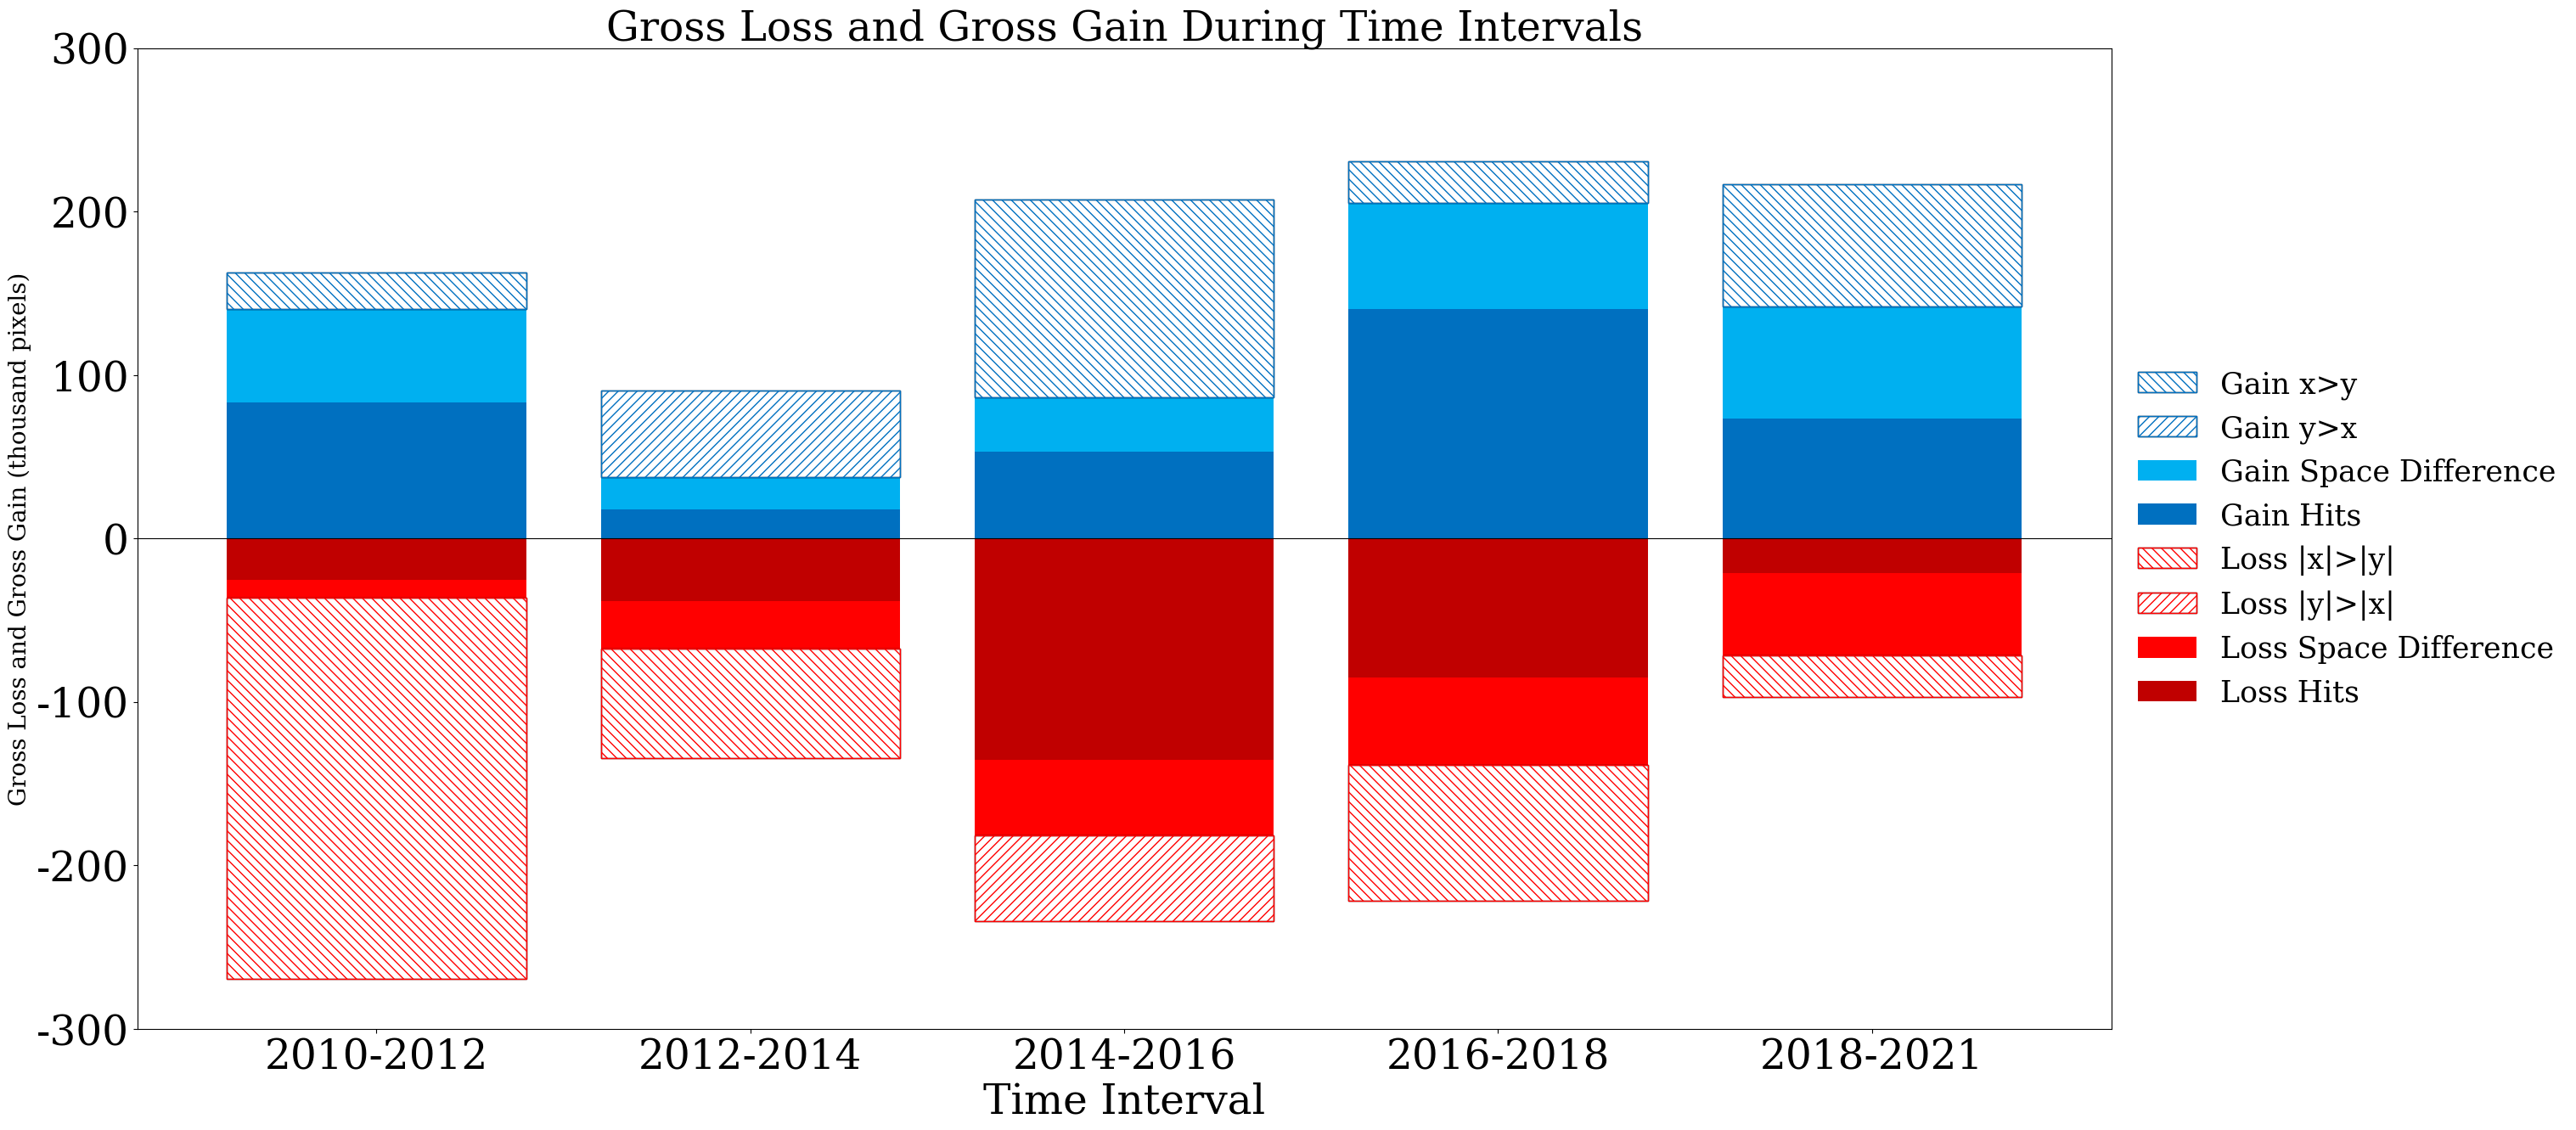


✅ Processing complete. Graphic saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2/gross_change_PIE.png


In [12]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.2 Data preparation
# -----------------------------------------------------------------------------
# plot_data_list = []

# for interval in time_intervals:
#     row_data = change_results_by_interval.get(interval, {})
#     row_data["Interval"] = interval
#     plot_data_list.append(row_data)

# sum_row_gross = sum_change_results.copy()
# sum_row_gross["Interval"] = "Sum"
# plot_data_list.append(sum_row_gross)

# extent_row_gross = extent_results.copy()
# extent_row_gross["Interval"] = f"{time_points[0]}-{time_points[-1]}"
# plot_data_list.append(extent_row_gross)

# df_plot = pd.DataFrame(plot_data_list).set_index("Interval").fillna(0)
# labels = df_plot.index.tolist()

# gain_colors = {
#     "Hits": "#0070C0",
#     "Space Difference": "#00B0F0",
#     "Time Difference": "#BDD7EE",
#     "Miss": "white",
#     "False Alarm": "white"
# }
# loss_colors = {
#     "Hits": "#C00000",
#     "Space Difference": "#FF0000",
#     "Time Difference": "#FF9696",
#     "Miss": "white",
#     "False Alarm": "white"
# }
# gain_hatch_color = "#0070C0"
# loss_hatch_color = "#FF0000"

plot_data_list = []

for interval in time_intervals:
    row_data = change_results_by_interval.get(interval, {})
    row_data["Interval"] = interval
    plot_data_list.append(row_data)

# continua calculando sum e extent (se precisar em tabela/export)
sum_row_gross = sum_change_results.copy()
sum_row_gross["Interval"] = "Sum"
plot_data_list.append(sum_row_gross)

extent_row_gross = extent_results.copy()
extent_row_gross["Interval"] = f"{time_points[0]}-{time_points[-1]}"
plot_data_list.append(extent_row_gross)

# cria dataframe
df_plot = pd.DataFrame(plot_data_list).set_index("Interval").fillna(0)

# remove as duas últimas linhas apenas do gráfico
extent_label = f"{time_points[0]}-{time_points[-1]}"
df_plot = df_plot.drop(["Sum", extent_label], errors="ignore")

labels = df_plot.index.tolist()

gain_colors = {
    "Hits": "#0070C0",
    "Space Difference": "#00B0F0",
    "Time Difference": "#BDD7EE",
    "Miss": "white",
    "False Alarm": "white"
}
loss_colors = {
    "Hits": "#C00000",
    "Space Difference": "#FF0000",
    "Time Difference": "#FF9696",
    "Miss": "white",
    "False Alarm": "white"
}
gain_hatch_color = "#0070C0"
loss_hatch_color = "#FF0000"

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(30, 15)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# -----------------------------------------------------------------------------
# 1.4 Bars — Gains
# -----------------------------------------------------------------------------

bottom_gain = np.zeros(len(labels))

for comp in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    disp = "x>y" if comp == "Miss" else ("y>x" if comp == "False Alarm" else comp)
    col = f"Gain {comp}"
    data = df_plot[col].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Gain {disp}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Gain {disp}",
            color=gain_colors[comp],
            bottom=bottom_gain,
            edgecolor="none"
        )
    bottom_gain += data

# -----------------------------------------------------------------------------
# 1.5 Bars — Losses
# -----------------------------------------------------------------------------
bottom_loss = np.zeros(len(labels))

for comp in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    disp = "|x|>|y|" if comp == "Miss" else ("|y|>|x|" if comp == "False Alarm" else comp)
    col = f"Loss {comp}"
    data = df_plot[col].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Loss {disp}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Loss {disp}",
            color=loss_colors[comp],
            bottom=bottom_loss,
            edgecolor="none"
        )
    bottom_loss += data

# -----------------------------------------------------------------------------
# 1.6 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="\\\\\\")
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="///")
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="\\\\\\")
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="///")
)

order = [
    "Gain x>y",
    "Gain y>x",
    # "Gain Time Difference",
    "Gain Space Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    # "Loss Time Difference",
    "Loss Space Difference",
    "Loss Hits"
]

ordered_handles = [legend_dict.get(label) for label in order if label in legend_dict]
ordered_labels  = [label for label in order if label in legend_dict]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=25,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

# -----------------------------------------------------------------------------
# 1.7 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Gross Loss and Gross Gain During Time Intervals",
    fontsize=35
)
ax.set_xlabel(
    "Time Interval",
    fontsize=35
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=35,
    rotation=0
)

ax.tick_params(
    axis="y",
    which="major",
    labelsize=35,
    # rotation=90
)
# ax.yaxis.set_major_locator(MultipleLocator(1))

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.autoscale(enable=False, axis="y")
# ax.set_ylim(
#     -6,
#      6
# )
# ax.margins(y=0)
# # ax.set_yticks(np.arange(-8, 14 + 1, 2))
# ax.set_ylabel(
#     "Gross Loss and Gross Gain",
#     fontsize=35
# )

# Option 2: For large values (divide by 1 million)
# def millions_formatter(y, pos):
#     return f"{y / 1_000_000:.0f}"
# ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
# # ax.set_ylim(
# #     -2_000_000,
# #      2_000_000
# # )
# ax.set_ylabel(
#     "Gross Loss and Gross Gain (million pixels)",
#     fontsize=35
# )

# Option 3: For large values (divide by 1 thousand)
def thousands_formatter(y, pos):
    return f"{y / 1_000:.0f}"
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.set_ylim(-300_000, 300_000)
ax.set_ylabel(
    "Gross Loss and Gross Gain (thousand pixels)",
    fontsize=20
)

# =============================================================================
# 1.8 Save figure
# =============================================================================
output_filename = f"gross_change_{class_name}.png"
final_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_path}")

##### 4.2.2 Bar plot of Sum and Extent


Plotting only 'Sum' and 'Extent' bars...


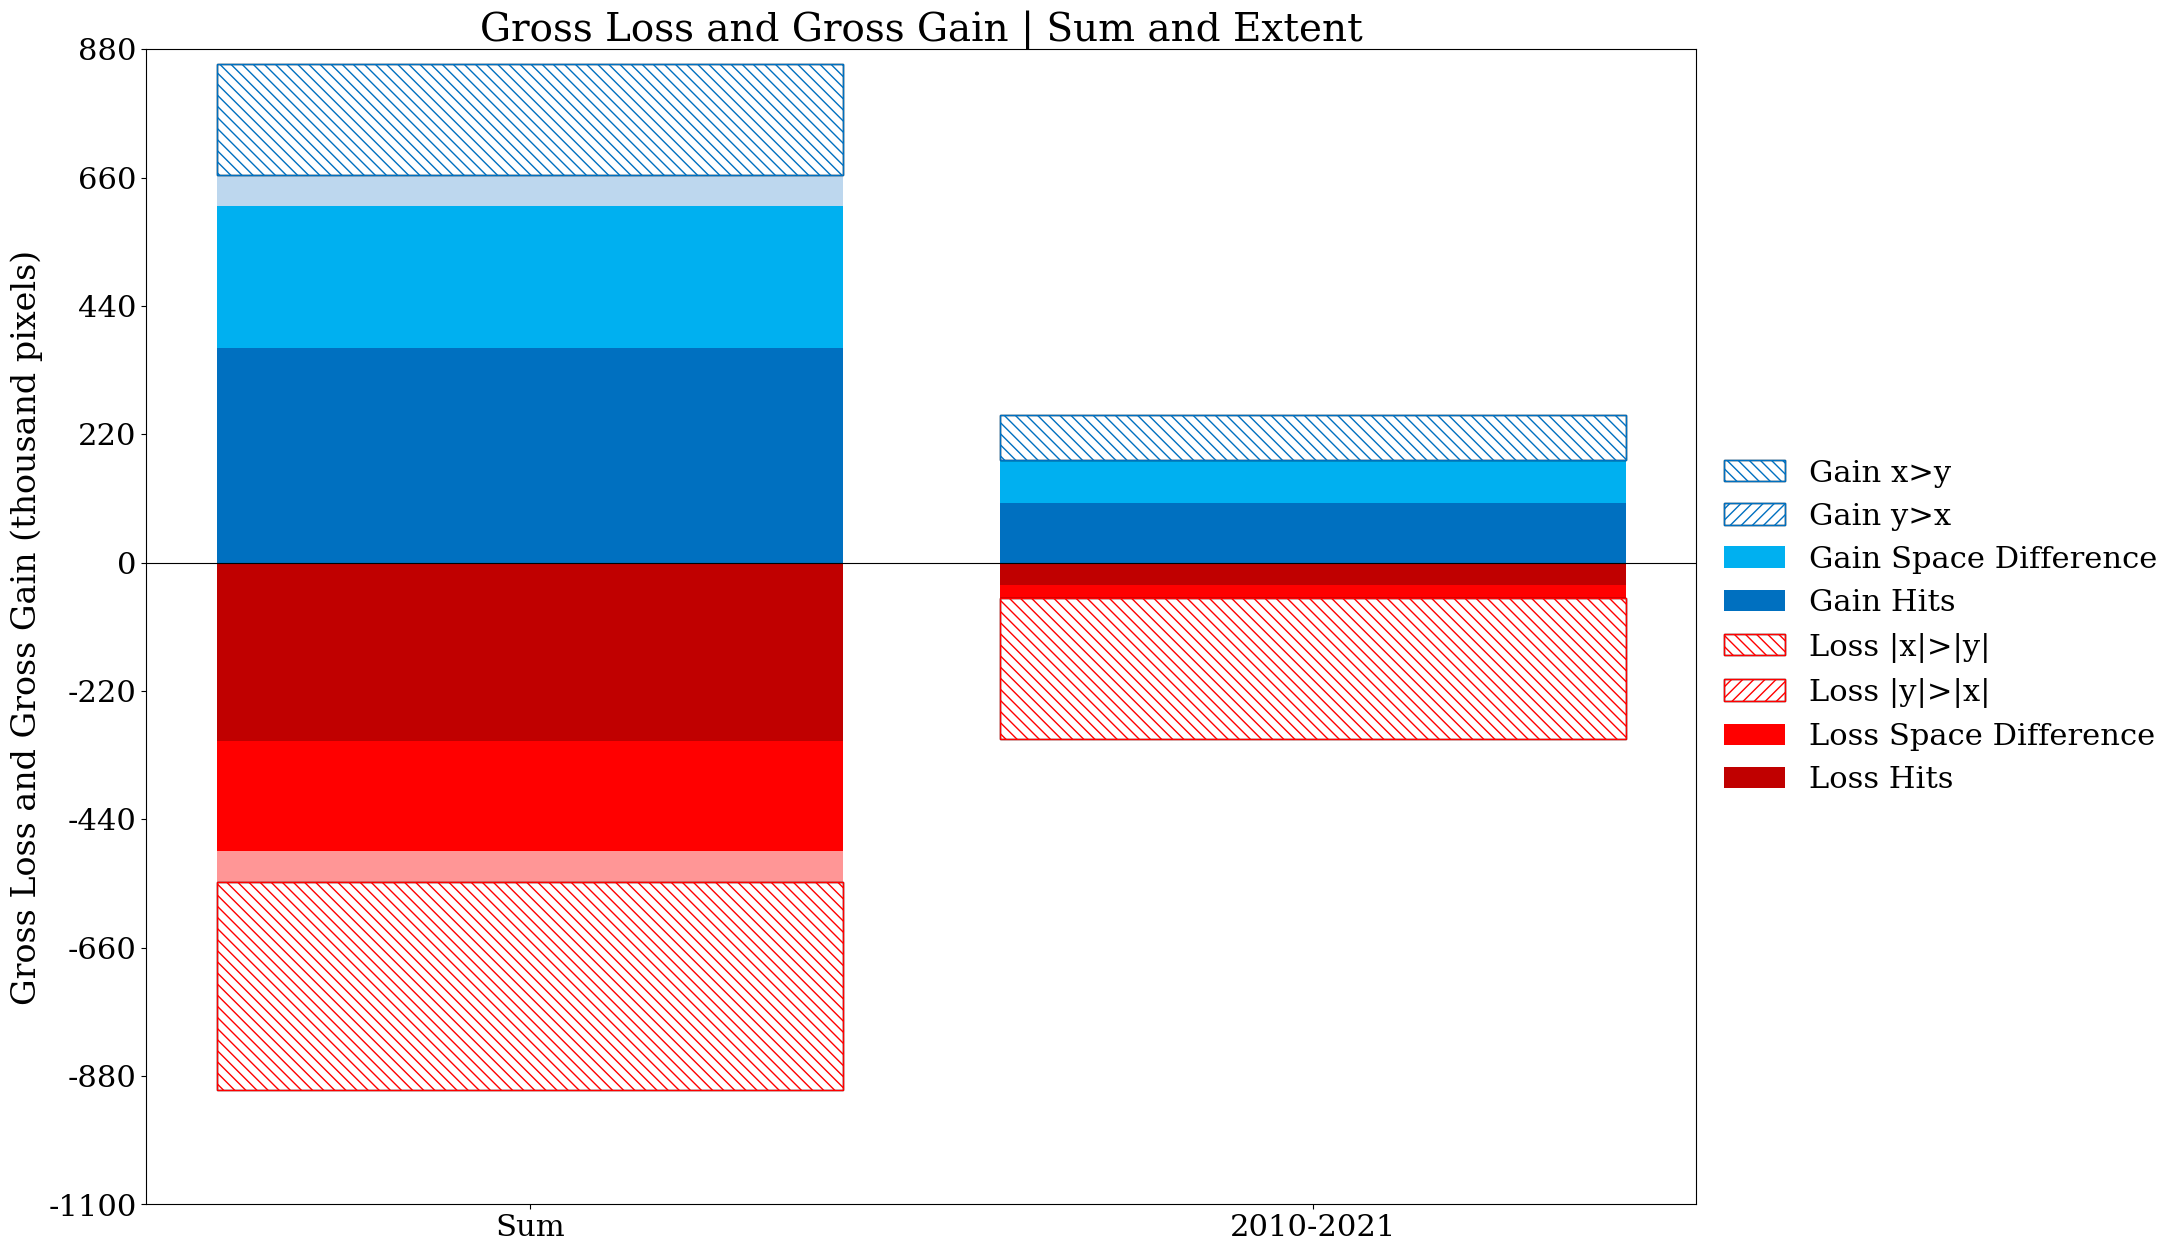


✅ Plot saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2/gross_change_sum_extent_PIE.png


In [ ]:
# =============================================================================
# Plot ONLY "Sum" and "Extent" bars (same style as main chart)
# =============================================================================
print("\nPlotting only 'Sum' and 'Extent' bars...")

# --- defaults in case they were not defined earlier ---
if "gain_colors" not in globals():
    gain_colors = {
        "Hits": "#0070C0",
        "Space Difference": "#00B0F0",
        "Time Difference": "#BDD7EE",
        "Miss": "white",
        "False Alarm": "white",
    }
if "loss_colors" not in globals():
    loss_colors = {
        "Hits": "#C00000",
        "Space Difference": "#FF0000",
        "Time Difference": "#FF9696",
        "Miss": "white",
        "False Alarm": "white",
    }

gain_hatch_color = globals().get(
    "gain_hatch_color",
    "#0070C0",
)
loss_hatch_color = globals().get(
    "loss_hatch_color",
    "#FF0000",
)

# Labels for the two summary bars
extent_label = f"{time_points[0]}-{time_points[-1]}"

# Build dataframe with only Sum and Extent
sum_row_gross = dict(sum_change_results)
sum_row_gross["Interval"] = "Sum"

extent_row_gross = dict(extent_results)
extent_row_gross["Interval"] = extent_label

df_plot_se = (
    pd.DataFrame(
        [sum_row_gross, extent_row_gross],
    )
    .set_index("Interval")
    .fillna(0)
)

# Enforce single-side quantity residuals in "Sum" (one side only)
Lx = float(sum_change_results.get("Loss Total X", 0.0))  # ≤ 0
Ly = float(sum_change_results.get("Loss Total Y", 0.0))  # ≤ 0
mag_x = -Lx
mag_y = -Ly
loss_x_gt_y_sum = -(mag_x - mag_y) if mag_x > mag_y else 0.0  # negative
loss_y_gt_x_sum = -(mag_y - mag_x) if mag_y > mag_x else 0.0  # negative
df_plot_se.loc["Sum", "Loss Miss"] = loss_x_gt_y_sum
df_plot_se.loc["Sum", "Loss False Alarm"] = loss_y_gt_x_sum

Gx = float(sum_change_results.get("Gain Total X", 0.0))  # ≥ 0
Gy = float(sum_change_results.get("Gain Total Y", 0.0))  # ≥ 0
df_plot_se.loc["Sum", "Gain Miss"] = max(0.0, Gx - Gy)  # x>y
df_plot_se.loc["Sum", "Gain False Alarm"] = max(0.0, Gy - Gx)  # y>x

labels_se = df_plot_se.index.tolist()

# Figure
fig, ax = plt.subplots(
    figsize=(20, 15),
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

mpl.rcParams["font.family"] = "serif"

# ----- Gains (stacked, positive) -----
bottom_gain = np.zeros(
    len(labels_se),
)

for comp in [
    "Hits",
    "Space Difference",
    "Time Difference",
    "Miss",
    "False Alarm",
]:
    disp = (
        "x>y"
        if comp == "Miss"
        else (
            "y>x"
            if comp == "False Alarm"
            else comp
        )
    )
    col = f"Gain {comp}"
    data = (
        df_plot_se[col].values
        if col in df_plot_se.columns
        else np.zeros(len(labels_se))
    )

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"
        ax.bar(
            labels_se,
            plot_data,
            label=f"Gain {disp}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black",
        )
        ax.bar(
            labels_se,
            plot_data,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch,
        )
    else:
        ax.bar(
            labels_se,
            data,
            label=f"Gain {disp}",
            color=gain_colors.get(comp, "#cccccc"),
            bottom=bottom_gain,
            edgecolor="none",
        )
    bottom_gain += data

# ----- Losses (stacked, negative values expected in df) -----
bottom_loss = np.zeros(
    len(labels_se),
)

for comp in [
    "Hits",
    "Space Difference",
    "Time Difference",
    "Miss",
    "False Alarm",
]:
    disp = (
        "|x|>|y|"
        if comp == "Miss"
        else (
            "|y|>|x|"
            if comp == "False Alarm"
            else comp
        )
    )
    col = f"Loss {comp}"
    data = (
        df_plot_se[col].values
        if col in df_plot_se.columns
        else np.zeros(len(labels_se))
    )

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"
        ax.bar(
            labels_se,
            plot_data,
            label=f"Loss {disp}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black",
        )
        ax.bar(
            labels_se,
            plot_data,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch,
        )
    else:
        ax.bar(
            labels_se,
            data,
            label=f"Loss {disp}",
            color=loss_colors.get(comp, "#f2aaaa"),
            bottom=bottom_loss,
            edgecolor="none",
        )
    bottom_loss += data

# ----- Legend (ordered, without Time Difference in composite hatch groups) -----
handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="\\\\\\",
    ),
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="///",
    ),
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="\\\\\\",
    ),
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="///",
    ),
)

order = [
    "Gain x>y",
    "Gain y>x",
    "Gain Space Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    "Loss Space Difference",
    "Loss Hits",
]

ordered_handles = [
    legend_dict.get(label)
    for label in order
    if label in legend_dict
]
ordered_labels = [
    label
    for label in order
    if label in legend_dict
]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=22,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left",
)

# ----- Axes & title -----
ax.set_title(
    "Gross Loss and Gross Gain | Sum and Extent",
    fontsize=28,
)

ax.tick_params(
    axis="x",
    which="major",
    labelsize=22,
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=22,
)

# Robust y-axis: round limits, large step, no minor ticks, thousands formatter
ymax = float(np.nanmax(bottom_gain))
ymin = float(np.nanmin(bottom_loss))
rng = max(1.0, ymax - ymin)
target_majors = 8
step = int(np.ceil(rng / target_majors / 1000.0)) * 1000
if step <= 0:
    step = 1000

y0 = int(np.floor(ymin / step) * step)
y1 = int(np.ceil(ymax / step) * step)
if y0 == y1:
    y1 = y0 + step

ax.set_ylim(
    y0,
    y1,
)
ax.yaxis.set_major_locator(
    MultipleLocator(
        base=step,
    ),
)
ax.yaxis.set_minor_locator(
    NullLocator(),
)
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda y, pos: f"{int(y / 1000)}",
    ),
)

ax.set_ylabel(
    "Gross Loss and Gross Gain (thousand pixels)",
    fontsize=24,
)

# ----- Save -----
out_name = f"gross_change_sum_extent_{class_name}.png"
final_path = os.path.join(
    output_path,
    out_name,
)

plt.savefig(
    final_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"\n✅ Plot saved as: {final_path}")

#### 4.3 Net Change

##### 4.3.1 Time Intervals


Making the graphic...


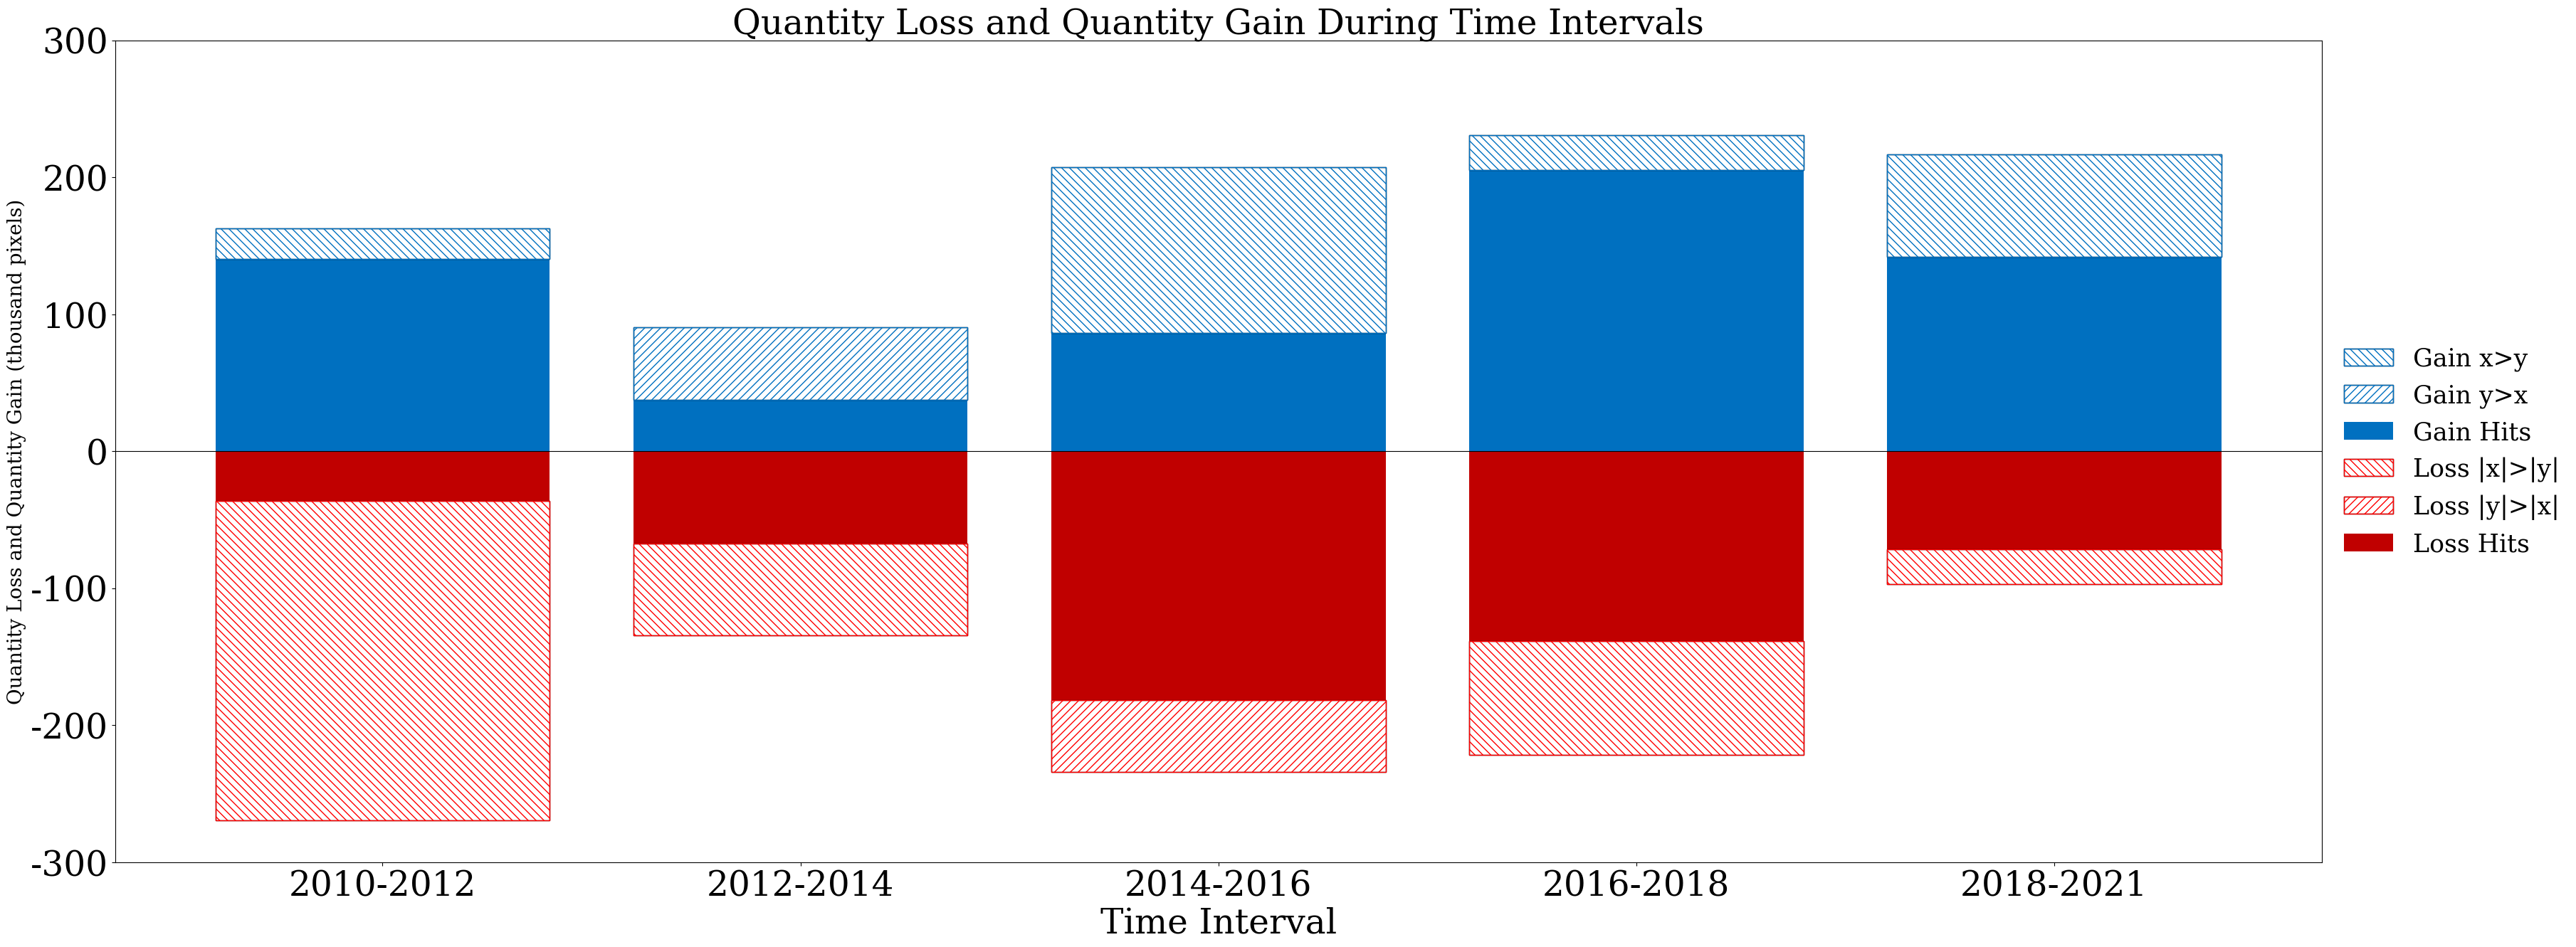


✅ Processing complete. Graphic saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2/net_change_PIE.png


In [19]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.2 Data preparation
# -----------------------------------------------------------------------------
# net_plot_data_list = []

# for interval in time_intervals:
#     row_data = net_change_by_interval.get(interval, {})
#     row_data["Interval"] = interval
#     net_plot_data_list.append(row_data)

# sum_row_net = sum_net_results.copy()
# sum_row_net["Interval"] = "Sum"
# net_plot_data_list.append(sum_row_net)

# extent_row_net = net_extent_results.copy()
# extent_row_net["Interval"] = f"{time_points[0]}-{time_points[-1]}"
# net_plot_data_list.append(extent_row_net)

# df_plot_net = pd.DataFrame(net_plot_data_list).set_index("Interval").fillna(0)
# labels = df_plot_net.index.tolist()

# gain_colors = {
#     "Hits": "#0070C0",
#     "Time Difference": "#BDD7EE",
#     "Miss": "white",
#     "False Alarm": "white"
# }
# loss_colors = {
#     "Hits": "#C00000",
#     "Time Difference": "#FF9696",
#     "Miss": "white",
#     "False Alarm": "white"
# }
# gain_hatch_color = "#0070C0"
# loss_hatch_color = "#FF0000"

# -----------------------------------------------------------------------------
# 1.2 Data preparation
# -----------------------------------------------------------------------------
net_plot_data_list = []

for interval in time_intervals:
    row_data = net_change_by_interval.get(interval, {})
    row_data["Interval"] = interval
    net_plot_data_list.append(row_data)

# continua guardando Sum e extent, caso precise em tabelas/exportações
sum_row_net = sum_net_results.copy()
sum_row_net["Interval"] = "Sum"
net_plot_data_list.append(sum_row_net)

extent_row_net = net_extent_results.copy()
extent_row_net["Interval"] = f"{time_points[0]}-{time_points[-1]}"
net_plot_data_list.append(extent_row_net)

# cria DataFrame
df_plot_net = pd.DataFrame(net_plot_data_list).set_index("Interval").fillna(0)

# remove 'Sum' e extent antes de gerar o gráfico
extent_label = f"{time_points[0]}-{time_points[-1]}"
df_plot_net = df_plot_net.drop(["Sum", extent_label], errors="ignore")

# labels para plotagem
labels = df_plot_net.index.tolist()


# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(40, 15)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# -----------------------------------------------------------------------------
# 1.4 Bars — Net Gains
# -----------------------------------------------------------------------------
bottom_gain = np.zeros(len(labels))

for comp in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    # final legend text (no post-remap needed)
    disp = (
        "x>y" if comp == "Miss"
        else ("y>x" if comp == "False Alarm" else comp)
    )

    data = df_plot_net[f"Gain {comp}"].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Gain {disp}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Gain {disp}",
            color=gain_colors[comp],
            bottom=bottom_gain,
            edgecolor="none"
        )
    bottom_gain += data

# -----------------------------------------------------------------------------
# 1.5 Bars — Net Losses
# -----------------------------------------------------------------------------
bottom_loss = np.zeros(len(labels))

for comp in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    # final legend text (no post-remap needed)
    disp = (
        "|x|>|y|" if comp == "Miss"
        else ("|y|>|x|" if comp == "False Alarm" else comp)
    )

    data = df_plot_net[f"Loss {comp}"].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Loss {disp}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Loss {disp}",
            color=loss_colors[comp],
            bottom=bottom_loss,
            edgecolor="none"
        )
    bottom_loss += data

# -----------------------------------------------------------------------------
# 1.6 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

# custom patches for hatched entries
legend_dict["Gain x>y"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="\\\\\\")
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="///")
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="\\\\\\")
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="///")
)

order = [
    "Gain x>y",
    "Gain y>x",
    # "Gain Time Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    # "Loss Time Difference",
    "Loss Hits"
]

ordered_handles = [legend_dict.get(label) for label in order if label in legend_dict]
ordered_labels  = [label for label in order if label in legend_dict]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=25,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

# -----------------------------------------------------------------------------
# 1.7 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Quantity Loss and Quantity Gain During Time Intervals",
    fontsize=35
)
ax.set_xlabel(
    "Time Interval",
    fontsize=35
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=35,
    rotation=0
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=35
)
# ax.yaxis.set_major_locator(MultipleLocator(1))

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.autoscale(enable=False, axis="y")
# ax.set_ylim(-6, 6)
# ax.margins(y=0)
# ax.set_yticks(np.arange(-8, 14 + 1, 2))
ax.set_ylabel(
    "Quantity Loss and Quantity Gain",
    fontsize=18
)

# Option 2: For real data with large values
# def millions_formatter(y, pos):
#     return f"{y / 1_000_000:.0f}"

# ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
# # ax.set_ylim(
# #     -2_000_000,
# #      2_000_000
# # )
# ax.set_ylabel(
#     "Quantity Loss and Quantity Gain (million pixels)",
#     fontsize=30
# )

# Option 3: For real data with large values (thousand)
def thousands_formatter(y, pos):
    return f"{y / 1_000:.0f}"
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.set_ylim(-300_000, 300_000)
ax.set_ylabel(
    "Quantity Loss and Quantity Gain (thousand pixels)",
    fontsize=20
)

# =============================================================================
# 1.8 Save figure
# =============================================================================
output_filename = f"net_change_{class_name}.png"
final_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_path}")


##### 4.3.2 Sum and Extent


Plotting NET 'Sum' and 'Extent' bars...


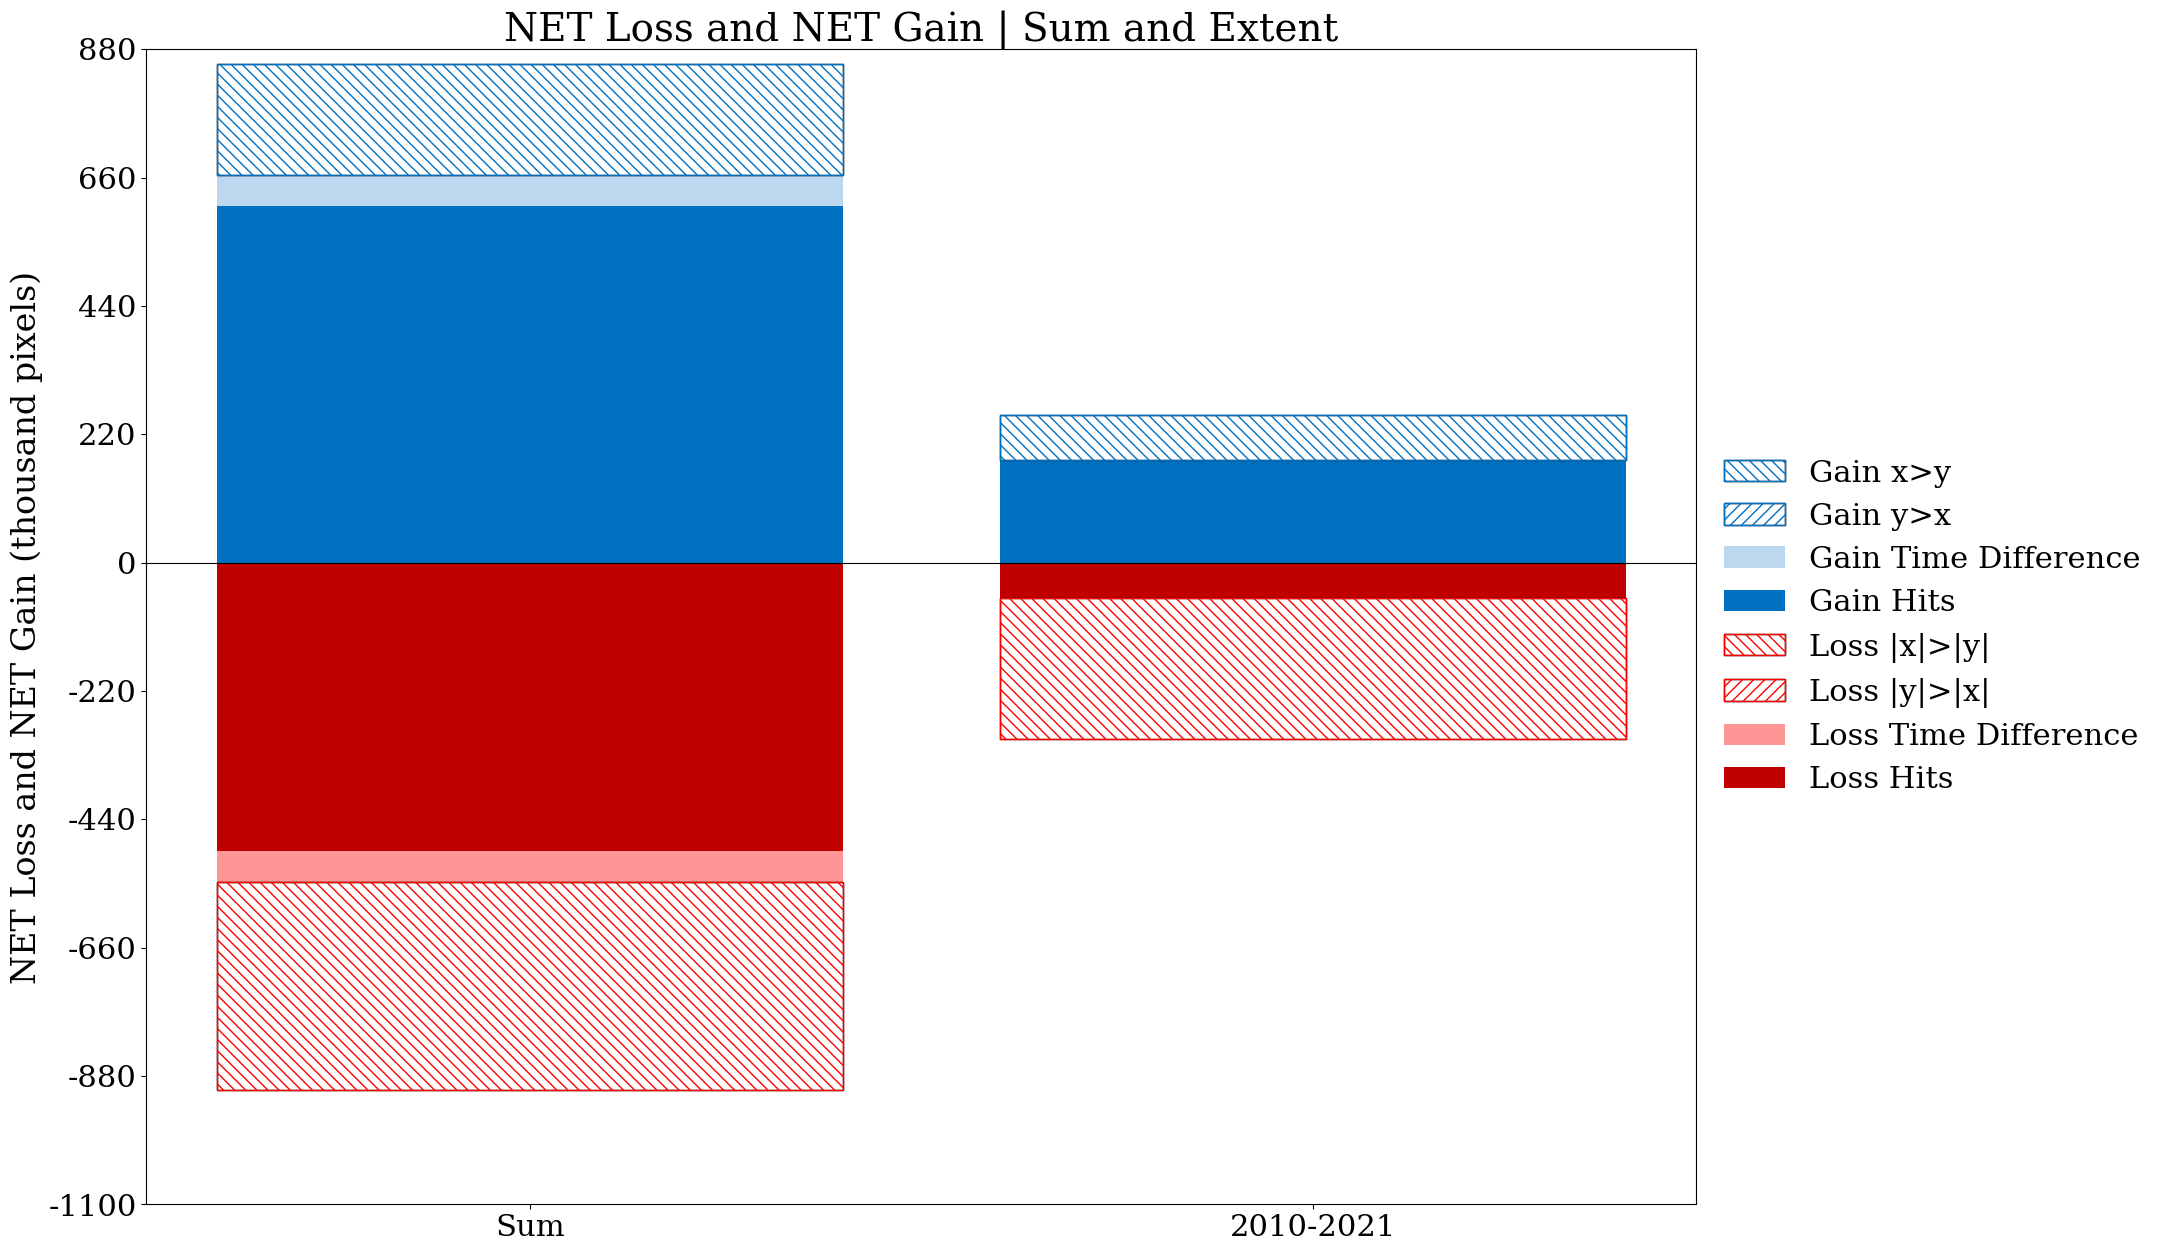


✅ Plot saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2/net_change_sum_extent_PIE.png


In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator, FuncFormatter, NullLocator

# =============================================================================
# Plot ONLY "Sum" and "Extent" bars for NET change (Gain/Loss)
# =============================================================================

print("\nPlotting NET 'Sum' and 'Extent' bars...")

# --- colors (defaults if not defined earlier) ---
if "gain_colors" not in globals():
    gain_colors = {
        "Hits": "#0070C0",
        "Time Difference": "#BDD7EE",
        "Miss": "white",
        "False Alarm": "white",
    }
if "loss_colors" not in globals():
    loss_colors = {
        "Hits": "#C00000",
        "Time Difference": "#FF9696",
        "Miss": "white",
        "False Alarm": "white",
    }

gain_hatch_color = globals().get(
    "gain_hatch_color",
    "#0070C0",
)
loss_hatch_color = globals().get(
    "loss_hatch_color",
    "#FF0000",
)

mpl.rcParams["font.family"] = "serif"

# ----- build rows: Sum (over intervals) and Extent (first→last) -----
# Sum row (use totals and summed hits; ensure single-side residuals)
qgx_sum = float(sum_net_results.get("QG_Total_X", 0.0))          # ≥ 0
qgy_sum = float(sum_net_results.get("QG_Total_Y", 0.0))          # ≥ 0
qlx_sum = float(sum_net_results.get("QL_Total_X", 0.0))          # ≤ 0
qly_sum = float(sum_net_results.get("QL_Total_Y", 0.0))          # ≤ 0

gain_hit_sum = float(sum_net_results.get("Gain Hits", 0.0))      # ≥ 0
loss_hit_sum = float(sum_net_results.get("Loss Hits", 0.0))      # ≤ 0

gain_td_sum = float(sum_net_results.get("Gain Time Difference", 0.0))          # ≥ 0
loss_td_mag_sum = float(sum_net_results.get("Loss Time Difference", 0.0))      # magnitude (≥ 0)

gain_common_sum = min(qgx_sum, qgy_sum)
loss_common_sum = max(qlx_sum, qly_sum)  # less negative

gain_miss_sum = qgx_sum - gain_common_sum                  # ≥ 0 (x>y)
gain_fa_sum = qgy_sum - gain_common_sum                    # ≥ 0 (y>x)
loss_miss_sum = qlx_sum - loss_common_sum                  # ≤ 0 (|x|>|y|)
loss_fa_sum = qly_sum - loss_common_sum                    # ≤ 0 (|y|>|x|)
loss_td_sum = -abs(loss_td_mag_sum)                        # plot as negative

sum_row = {
    "Interval": "Sum",
    "Gain Hits": gain_hit_sum,
    "Gain Time Difference": gain_td_sum,
    "Gain Miss": gain_miss_sum,
    "Gain False Alarm": gain_fa_sum,
    "Loss Hits": loss_hit_sum,
    "Loss Time Difference": loss_td_sum,
    "Loss Miss": loss_miss_sum,
    "Loss False Alarm": loss_fa_sum,
}

# Extent row (no time difference at extent)
qgx_ext = float(net_extent_results.get("QG_Total_X", 0.0))        # ≥ 0
qgy_ext = float(net_extent_results.get("QG_Total_Y", 0.0))        # ≥ 0
qlx_ext = float(net_extent_results.get("QL_Total_X", 0.0))        # ≤ 0
qly_ext = float(net_extent_results.get("QL_Total_Y", 0.0))        # ≤ 0

gain_hit_ext = float(net_extent_results.get("Gain Hits", 0.0))    # ≥ 0
loss_hit_ext = float(net_extent_results.get("Loss Hits", 0.0))    # ≤ 0

gain_common_ext = min(qgx_ext, qgy_ext)
loss_common_ext = max(qlx_ext, qly_ext)

gain_miss_ext = qgx_ext - gain_common_ext                         # ≥ 0
gain_fa_ext = qgy_ext - gain_common_ext                           # ≥ 0
loss_miss_ext = qlx_ext - loss_common_ext                         # ≤ 0
loss_fa_ext = qly_ext - loss_common_ext                           # ≤ 0

extent_label = f"{time_points[0]}-{time_points[-1]}"
extent_row = {
    "Interval": extent_label,
    "Gain Hits": gain_hit_ext,
    "Gain Time Difference": 0.0,
    "Gain Miss": gain_miss_ext,
    "Gain False Alarm": gain_fa_ext,
    "Loss Hits": loss_hit_ext,
    "Loss Time Difference": 0.0,
    "Loss Miss": loss_miss_ext,
    "Loss False Alarm": loss_fa_ext,
}

# DataFrame
df_plot_se = (
    pd.DataFrame(
        [sum_row, extent_row],
    )
    .set_index("Interval")
    .fillna(0)
)

labels_se = df_plot_se.index.tolist()

# ----- figure -----
fig, ax = plt.subplots(
    figsize=(20, 15),
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

# ----- Gains (stacked, positive) -----
bottom_gain = np.zeros(
    len(labels_se),
)

for comp in [
    "Hits",
    "Time Difference",
    "Miss",
    "False Alarm",
]:
    disp = (
        "x>y"
        if comp == "Miss"
        else (
            "y>x"
            if comp == "False Alarm"
            else comp
        )
    )
    col = f"Gain {comp}"
    data = (
        df_plot_se[col].values
        if col in df_plot_se.columns
        else np.zeros(len(labels_se))
    )

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"
        ax.bar(
            labels_se,
            plot_data,
            label=f"Gain {disp}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black",
        )
        ax.bar(
            labels_se,
            plot_data,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch,
        )
    else:
        ax.bar(
            labels_se,
            data,
            label=f"Gain {disp}",
            color=gain_colors.get(comp, "#cccccc"),
            bottom=bottom_gain,
            edgecolor="none",
        )
    bottom_gain += data

# ----- Losses (stacked, negative) -----
bottom_loss = np.zeros(
    len(labels_se),
)

for comp in [
    "Hits",
    "Time Difference",
    "Miss",
    "False Alarm",
]:
    disp = (
        "|x|>|y|"
        if comp == "Miss"
        else (
            "|y|>|x|"
            if comp == "False Alarm"
            else comp
        )
    )
    col = f"Loss {comp}"
    data = (
        df_plot_se[col].values
        if col in df_plot_se.columns
        else np.zeros(len(labels_se))
    )

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"
        ax.bar(
            labels_se,
            plot_data,
            label=f"Loss {disp}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black",
        )
        ax.bar(
            labels_se,
            plot_data,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch,
        )
    else:
        ax.bar(
            labels_se,
            data,
            label=f"Loss {disp}",
            color=loss_colors.get(comp, "#f2aaaa"),
            bottom=bottom_loss,
            edgecolor="none",
        )
    bottom_loss += data

# ----- Legend (ordered; composite hatches shown; no TD in composite group) -----
handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="\\\\\\",
    ),
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="///",
    ),
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="\\\\\\",
    ),
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="///",
    ),
)

order = [
    "Gain x>y",
    "Gain y>x",
    "Gain Time Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    "Loss Time Difference",
    "Loss Hits",
]

ordered_handles = [
    legend_dict.get(label)
    for label in order
    if label in legend_dict
]
ordered_labels = [
    label
    for label in order
    if label in legend_dict
]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=22,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left",
)

# ----- Axes & title -----
ax.set_title(
    "NET Loss and NET Gain | Sum and Extent",
    fontsize=28,
)

ax.tick_params(
    axis="x",
    which="major",
    labelsize=22,
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=22,
)

# Robust y-axis in thousands, no decimals
ymax = float(np.nanmax(bottom_gain))
ymin = float(np.nanmin(bottom_loss))
rng = max(1.0, ymax - ymin)
target_majors = 8
step = int(np.ceil(rng / target_majors / 1000.0)) * 1000
if step <= 0:
    step = 1000

y0 = int(np.floor(ymin / step) * step)
y1 = int(np.ceil(ymax / step) * step)
if y0 == y1:
    y1 = y0 + step

ax.set_ylim(
    y0,
    y1,
)
ax.yaxis.set_major_locator(
    MultipleLocator(
        base=step,
    ),
)
ax.yaxis.set_minor_locator(
    NullLocator(),
)
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda y, pos: f"{int(y / 1000)}",
    ),
)

ax.set_ylabel(
    "NET Loss and NET Gain (thousand pixels)",
    fontsize=24,
)

# ----- Save -----
out_name = f"net_change_sum_extent_{class_name}.png"
final_path = os.path.join(
    output_path,
    out_name,
)

plt.savefig(
    final_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"\n✅ Plot saved as: {final_path}")


## 5. Export results

In [23]:
# =============================================================================
# 1. Export all graphic results to an Excel file
# =============================================================================
print("Starting the export of results to Excel...")

import pandas as pd

excel_filename = f"analysis_results_{class_name}.xlsx"
excel_final_path = os.path.join(
    output_path,
    excel_filename
)

with pd.ExcelWriter(excel_final_path, engine="xlsxwriter") as writer:

    # -----------------------------------------------------------------------------
    # ReadMe sheet
    # -----------------------------------------------------------------------------
    readme_text = (
        "This Excel file summarizes all results from the notebook.\n\n"
        "Sheet descriptions:\n\n"
        "- Presence Agreement:\n"
        "  Aggregated values for the Presence Agreement chart (Hits, Misses, etc.)\n"
        "  for each time point and the final sum.\n\n"
        "- Gross Change:\n"
        "  Values for the Gross Loss and Gain chart, showing all components of gross\n"
        "  change (including Space Difference) for each interval, the sum, and extent.\n\n"
        "- Net Change:\n"
        "  Values for the Net Change chart, showing quantity-based components of change\n"
        "  (without Space Difference) for each interval, the sum, and the extent."
    )
    df_readme = pd.DataFrame(
        {"File Description": [readme_text]}
    )
    df_readme.to_excel(
        writer,
        sheet_name="ReadMe",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Presence Agreement sheet
    # -----------------------------------------------------------------------------
    presence_data_list = []

    for tp in time_points:
        row_data = results_by_time.get(tp, {})
        row_data["Time Point"] = tp
        presence_data_list.append(row_data)

    sum_row_presence = sum_results.copy()
    sum_row_presence["Time Point"] = "Sum"
    presence_data_list.append(sum_row_presence)

    df_presence = pd.DataFrame(presence_data_list)

    presence_cols_order = [
        "Time Point",
        "Hit",
        "Space Difference",
        "Time Difference",
        "Miss",
        "False Alarm",
        "Total X",
        "Total Y"
    ]
    df_presence = (
        df_presence[presence_cols_order]
        .fillna(0)
    )

    df_presence.to_excel(
        writer,
        sheet_name="Presence Agreement",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Gross Change sheet
    # -----------------------------------------------------------------------------
    gross_change_data_list = []

    for interval in time_intervals:
        row_data = change_results_by_interval.get(interval, {})
        row_data["Interval"] = interval
        gross_change_data_list.append(row_data)

    sum_row_gross = sum_change_results.copy()
    sum_row_gross["Interval"] = "Sum"
    gross_change_data_list.append(sum_row_gross)

    extent_row_gross = extent_results.copy()
    extent_row_gross["Interval"] = f"{time_points[0]}-{time_points[-1]}"
    gross_change_data_list.append(extent_row_gross)

    df_gross = pd.DataFrame(gross_change_data_list)

    gross_cols_order = [
        "Interval",
        "Gain Hits",
        "Gain Space Difference",
        "Gain Time Difference",
        "Gain Miss",
        "Gain False Alarm",
        "Loss Hits",
        "Loss Space Difference",
        "Loss Time Difference",
        "Loss Miss",
        "Loss False Alarm"
    ]
    df_gross = (
        df_gross[gross_cols_order]
        .fillna(0)
    )

    df_gross.to_excel(
        writer,
        sheet_name="Gross Change",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Net Change sheet
    # -----------------------------------------------------------------------------
    net_change_data_list = []

    for interval in time_intervals:
        row_data = net_change_by_interval.get(interval, {})
        row_data["Interval"] = interval
        net_change_data_list.append(row_data)

    sum_row_net = sum_net_results.copy()
    sum_row_net["Interval"] = "Sum"
    net_change_data_list.append(sum_row_net)

    extent_row_net = net_extent_results.copy()
    extent_row_net["Interval"] = f"{time_points[0]}-{time_points[-1]}"
    net_change_data_list.append(extent_row_net)

    df_net = pd.DataFrame(net_change_data_list)

    net_cols_order = [
        "Interval",
        "Gain Hits",
        "Gain Time Difference",
        "Gain Miss",
        "Gain False Alarm",
        "Loss Hits",
        "Loss Time Difference",
        "Loss Miss",
        "Loss False Alarm"
    ]
    df_net = (
        df_net[net_cols_order]
        .fillna(0)
    )

    df_net.to_excel(
        writer,
        sheet_name="Net Change",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Auto-adjust column widths
    # -----------------------------------------------------------------------------
    workbook = writer.book

    for sheet_name, df in {
        "ReadMe": df_readme,
        "Presence Agreement": df_presence,
        "Gross Change": df_gross,
        "Net Change": df_net
    }.items():

        worksheet = writer.sheets[sheet_name]

        if sheet_name == "ReadMe":
            worksheet.set_column("A:A", 80)
            cell_format = workbook.add_format(
                {"valign": "top", "text_wrap": True}
            )
            worksheet.set_row(0, 150, cell_format)
        else:
            for idx, col in enumerate(df.columns):
                series = df[col].astype(str)
                max_len = max(series.map(len).max(), len(str(col))) + 2
                worksheet.set_column(idx, idx, max_len)

print(f"\n✅ All results successfully exported to: {excel_final_path}")

Starting the export of results to Excel...

✅ All results successfully exported to: /mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2/analysis_results_PIE.xlsx


# 6. Maps

## 6.1 Equation 49

In [ ]:
import os
import numpy as np
import rasterio


IN_NODATA = 255
OUT_NODATA = 255


def read_raster_stack(
    folder_path: str,
    time_points: list,
    class_name: str,
) -> np.ndarray:
    """
    Read a time series of single-band rasters and return an array
    with shape (T, H, W), where T is the number of time points.

    Args:
        folder_path: directory containing the rasters
        time_points: list of time labels
        class_name: filename prefix before the time label

    Returns:
        np.ndarray of shape (T, H, W), dtype uint8
    """
    rasters = []
    for t in time_points:
        filename = os.path.join(
            folder_path,
            f"{class_name}{t}.tif"
        )
        with rasterio.open(filename) as src:
            arr = src.read(1).astype(np.uint8)
            rasters.append(arr)
    stack = np.stack(
        rasters,
        axis=0
    )
    return stack


def equation_49_hit_sum_raster(
    x: np.ndarray,
    y: np.ndarray,
    nodata_value: int = 255,
    out_nodata_value: int = 255,
) -> np.ndarray:
    """
    Compute A_n for each pixel location (row, col).

    For each time t and pixel n:
        Ph_tn = min(Px_tn, Py_tn)

    A_n is the sum over t of Ph_tn.

    Only time steps where both x and y are not nodata_value
    contribute to the sum. Pixels that are never valid across
    all times are set to out_nodata_value.

    Args:
        x: np.ndarray, shape (T, H, W), dtype uint8
        y: np.ndarray, shape (T, H, W), dtype uint8
        nodata_value: value that encodes nodata in x and y
        out_nodata_value: value to assign to pixels that are
                          never valid

    Returns:
        np.ndarray of shape (H, W), dtype uint8
    """
    valid_mask = (
        (x != nodata_value) &
        (y != nodata_value)
    )

    hits = np.where(
        valid_mask,
        np.minimum(x, y),
        0
    ).astype(np.uint16)

    a_n_sum = hits.sum(
        axis=0
    ).astype(np.uint16)

    valid_any = valid_mask.any(
        axis=0
    )

    out_arr = a_n_sum.astype(np.uint8)
    out_arr[~valid_any] = out_nodata_value

    return out_arr


IN_PATH_X = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/pixelbasedZoom2"
IN_PATH_Y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/objectbasedZoom2"

TIME_POINTS = [
    2010,
    2012,
    2014,
    2016,
    2018,
    2021,
]

CLASS_NAME = "PIE"

OUT_DIR = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2"
if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)

x_stack = read_raster_stack(
    folder_path=IN_PATH_X,
    time_points=TIME_POINTS,
    class_name=CLASS_NAME,
)
y_stack = read_raster_stack(
    folder_path=IN_PATH_Y,
    time_points=TIME_POINTS,
    class_name=CLASS_NAME,
)

an_result = equation_49_hit_sum_raster(
    x=x_stack,
    y=y_stack,
    nodata_value=IN_NODATA,
    out_nodata_value=OUT_NODATA,
)

print("Equation 49 stats:")
print("  min:", an_result.min())
print("  max:", an_result.max())
print("  unique:", np.unique(an_result))
print("  dtype:", an_result.dtype)

with rasterio.open(
    os.path.join(
        IN_PATH_X,
        f"{CLASS_NAME}{TIME_POINTS[0]}.tif"
    )
) as src0:
    meta = src0.meta.copy()
    meta.update(
        count=1,
        dtype="uint8",
        nodata=OUT_NODATA,
        compress="lzw",
    )

OUT_FILE = os.path.join(
    OUT_DIR,
    "Equation49_result.tif"
)

with rasterio.open(
    OUT_FILE,
    "w",
    **meta
) as dst:
    dst.write(
        an_result,
        1
    )

print("Output raster saved to:", OUT_FILE)

## 6.2 Equation 50

In [ ]:
import os
import numpy as np
import rasterio


IN_NODATA = 255
OUT_NODATA = -128


def read_raster_stack(
    folder_path: str,
    time_points: list,
    class_name: str,
) -> np.ndarray:
    """
    Read a time series of single-band rasters.

    Args:
        folder_path: directory with rasters
        time_points: list of time labels
        class_name: filename prefix before the time label

    Returns:
        np.ndarray of shape (T, H, W), dtype int16
    """
    rasters = []
    for t in time_points:
        filename = os.path.join(
            folder_path,
            f"{class_name}{t}.tif"
        )
        with rasterio.open(filename) as src:
            arr = src.read(1).astype(np.int16)
            rasters.append(arr)
    return np.stack(rasters, axis=0)


def equation_50_difference_sum_raster(
    x: np.ndarray,
    y: np.ndarray,
    nodata_value: int = 255,
    out_nodata_value: int = -128,
) -> np.ndarray:
    """
    Compute B_n per pixel:

        B_n = sum_t (Py_tn - Px_tn)

    Args:
        x: np.ndarray, shape (T, H, W), dtype int16
        y: np.ndarray, shape (T, H, W), dtype int16
        nodata_value: nodata code in inputs
        out_nodata_value: nodata code in output

    Returns:
        np.ndarray of shape (H, W), dtype int8
    """
    valid = (x != nodata_value) & (y != nodata_value)
    diff = (y - x).astype(np.int16)
    diff[~valid] = 0
    bn = diff.sum(axis=0).astype(np.int16)

    valid_any = valid.any(axis=0)
    bn[~valid_any] = out_nodata_value

    return bn.astype(np.int8)


IN_PATH_X = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/pixelbasedZoom2"
IN_PATH_Y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/objectbasedZoom2"

TIME_POINTS = [
    2010,
    2012,
    2014,
    2016,
    2018,
    2021,
]

CLASS_NAME = "PIE"

OUT_DIR = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2"
os.makedirs(OUT_DIR, exist_ok=True)

x_stack = read_raster_stack(
    folder_path=IN_PATH_X,
    time_points=TIME_POINTS,
    class_name=CLASS_NAME,
)
y_stack = read_raster_stack(
    folder_path=IN_PATH_Y,
    time_points=TIME_POINTS,
    class_name=CLASS_NAME,
)

bn_result = equation_50_difference_sum_raster(
    x=x_stack,
    y=y_stack,
    nodata_value=IN_NODATA,
    out_nodata_value=OUT_NODATA,
)

print("Equation 50 stats:")
print("  min:", bn_result.min())
print("  max:", bn_result.max())
print("  unique:", np.unique(bn_result))
print("  dtype:", bn_result.dtype)

with rasterio.open(
    os.path.join(
        IN_PATH_X,
        f"{CLASS_NAME}{TIME_POINTS[0]}.tif"
    )
) as src0:
    meta = src0.meta.copy()
    meta.update(
        count=1,
        dtype="int8",
        nodata=OUT_NODATA,
        compress="lzw",
    )

OUT_FILE = os.path.join(
    OUT_DIR,
    "Equation50_result.tif"
)

with rasterio.open(
    OUT_FILE,
    "w",
    **meta
) as dst:
    dst.write(
        bn_result,
        1
    )

print("Output raster saved to:", OUT_FILE)

## 6.3 Equation 51

In [ ]:
import os
import numpy as np
import rasterio


IN_NODATA = 255
OUT_NODATA = 255


def read_raster_stack(
    folder_path: str,
    time_points: list,
    class_name: str,
) -> np.ndarray:
    """
    Read a time series of single-band rasters and return an array
    with shape (T, H, W), where T is the number of time points.

    Args:
        folder_path: directory containing the rasters
        time_points: list of time labels
        class_name: filename prefix before the time label

    Returns:
        np.ndarray of shape (T, H, W), dtype int16
    """
    rasters = []
    for t in time_points:
        filename = os.path.join(
            folder_path,
            f"{class_name}{t}.tif"
        )
        with rasterio.open(filename) as src:
            arr = src.read(1).astype(np.int16)
            rasters.append(arr)
    stack = np.stack(
        rasters,
        axis=0
    )
    return stack


def equation_51_temporal_allocation_difference_raster(
    x: np.ndarray,
    y: np.ndarray,
    nodata_value: int = 255,
    out_nodata_value: int = 255,
) -> np.ndarray:
    """
    Compute C_n for each pixel location (row, col).

    For each time t and pixel n:
        d_tn = Py_tn - Px_tn

    Let
        S1_n = sum_t |d_tn|
        S2_n = sum_t d_tn
        C_n  = S1_n - |S2_n|

    Only time steps where both x and y are not nodata_value
    contribute to the sums. Pixels that are never valid across
    all times are set to out_nodata_value.

    Args:
        x: np.ndarray, shape (T, H, W), dtype int16
        y: np.ndarray, shape (T, H, W), dtype int16
        nodata_value: nodata code in inputs
        out_nodata_value: nodata code in output

    Returns:
        np.ndarray of shape (H, W), dtype uint8
    """
    valid = (x != nodata_value) & (y != nodata_value)

    diff = (y - x).astype(np.int16)
    diff[~valid] = 0

    sum_abs_diff = np.abs(diff).sum(
        axis=0
    ).astype(np.int16)

    bn = diff.sum(
        axis=0
    ).astype(np.int16)

    cn = (sum_abs_diff - np.abs(bn)).astype(np.int16)

    valid_any = valid.any(
        axis=0
    )

    cn_clipped = np.clip(
        cn,
        0,
        254
    ).astype(np.uint16)

    out_arr = cn_clipped.astype(np.uint8)
    out_arr[~valid_any] = out_nodata_value

    return out_arr


IN_PATH_X = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/pixelbasedZoom2"
IN_PATH_Y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/objectbasedZoom2"

TIME_POINTS = [
    2010,
    2012,
    2014,
    2016,
    2018,
    2021,
]

CLASS_NAME = "PIE"

OUT_DIR = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2"
os.makedirs(OUT_DIR, exist_ok=True)

x_stack = read_raster_stack(
    folder_path=IN_PATH_X,
    time_points=TIME_POINTS,
    class_name=CLASS_NAME,
)
y_stack = read_raster_stack(
    folder_path=IN_PATH_Y,
    time_points=TIME_POINTS,
    class_name=CLASS_NAME,
)

cn_result = equation_51_temporal_allocation_difference_raster(
    x=x_stack,
    y=y_stack,
    nodata_value=IN_NODATA,
    out_nodata_value=OUT_NODATA,
)

print("Equation 51 stats:")
print("  min:", cn_result.min())
print("  max:", cn_result.max())
print("  unique:", np.unique(cn_result))
print("  dtype:", cn_result.dtype)

with rasterio.open(
    os.path.join(
        IN_PATH_X,
        f"{CLASS_NAME}{TIME_POINTS[0]}.tif"
    )
) as src0:
    meta = src0.meta.copy()
    meta.update(
        count=1,
        dtype="uint8",
        nodata=OUT_NODATA,
        compress="lzw",
    )

OUT_FILE = os.path.join(
    OUT_DIR,
    "Equation51_result.tif"
)

with rasterio.open(
    OUT_FILE,
    "w",
    **meta
) as dst:
    dst.write(
        cn_result,
        1
    )

print("Output raster saved to:", OUT_FILE)

## 6.4 Equation 52

In [ ]:
import os
import numpy as np
import rasterio


def read_raster_stack(
    folder_path: str,
    time_points: list,
    class_name: str,
) -> np.ndarray:
    """
    Read rasters as int16 so temporal differences can be negative.
    Returns array with shape (T, H, W), dtype int16.
    """
    rasters = []
    for t in time_points:
        filename = os.path.join(
            folder_path,
            f"{class_name}{t}.tif"
        )
        with rasterio.open(filename) as src:
            arr = src.read(1).astype(np.int16)
            rasters.append(arr)
    return np.stack(
        rasters,
        axis=0
    )


def equation_52_change_hits_raster(
    x: np.ndarray,
    y: np.ndarray,
    nodata_value: int = 255,
    out_nodata: int = 255,
) -> np.ndarray:
    """
    Compute Dn per pixel:
        Dn = sum_t (Gh_tn - Lh_tn)

    Gh_tn (gain hit): both dx > 0 and dy > 0
        value = min(dx, dy)  (>= 0)

    Lh_tn (loss hit): both dx < 0 and dy < 0
        value = max(dx, dy)  (<= 0)

    We ignore any interval where either map is nodata in t or t+1.

    Returns 2D array (H, W) with nonnegative scores,
    dtype uint8 in the final step.
    """
    # temporal diffs, now safe because x,y are int16
    dx = x[1:, ...] - x[:-1, ...]     # (T-1, H, W), int16
    dy = y[1:, ...] - y[:-1, ...]     # (T-1, H, W), int16

    # valid where both series are not nodata at t and t+1
    valid_mask = (
        (x[:-1, ...] != nodata_value) &
        (x[1:,  ...] != nodata_value) &
        (y[:-1, ...] != nodata_value) &
        (y[1:,  ...] != nodata_value)
    )

    # loss hit: both negative
    loss_hit = np.where(
        valid_mask & (dx < 0) & (dy < 0),
        np.maximum(dx, dy),   # this is <= 0
        0
    )

    # gain hit: both positive
    gain_hit = np.where(
        valid_mask & (dx > 0) & (dy > 0),
        np.minimum(dx, dy),   # this is >= 0
        0
    )

    # interval contribution = gain_hit - loss_hit
    # loss_hit is <= 0, so subtracting it adds a positive number
    dn_int16 = np.sum(
        gain_hit - loss_hit,
        axis=0
    ).astype(np.int16)

    # pixels with no valid interval at all -> out_nodata
    valid_any = valid_mask.any(axis=0)
    dn_int16[~valid_any] = out_nodata

    # clip any normal value to [0, 254] before cast to uint8
    # (reserve 255 for nodata)
    dn_clipped = np.clip(
        dn_int16,
        0,
        254
    )

    # force nodata where valid_any is False
    dn_clipped[~valid_any] = out_nodata

    # final output as uint8
    dn_uint8 = dn_clipped.astype(np.uint8)

    return dn_uint8


# user inputs
nodata_value = 255      # nodata in inputs
out_nodata = 255        # nodata in output (same code)

time_points = [
    2010,
    2012,
    2014,
    2016,
    2018,
    2021
]

class_name = "PIE"

path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/pixelbasedZoom2"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/objectbasedZoom2"

output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# read stacks as int16
x_stack = read_raster_stack(
    folder_path=path_series_x,
    time_points=time_points,
    class_name=class_name,
)
y_stack = read_raster_stack(
    folder_path=path_series_y,
    time_points=time_points,
    class_name=class_name,
)

# compute Dn
result = equation_52_change_hits_raster(
    x=x_stack,
    y=y_stack,
    nodata_value=nodata_value,
    out_nodata=out_nodata,
)

print("Result stats:")
print("  min:", result.min())
print("  max:", result.max())
print("  unique:", np.unique(result))
print("  dtype:", result.dtype)

# write GeoTIFF using uint8 and nodata=255
with rasterio.open(
    os.path.join(
        path_series_x,
        f"{class_name}{time_points[0]}.tif"
    )
) as src0:
    meta = src0.meta.copy()
    meta.update(
        count=1,
        dtype="uint8",
        nodata=out_nodata,
        compress="lzw",
    )

output_file = os.path.join(
    output_path,
    "Equation52_result.tif"
)

with rasterio.open(
    output_file,
    "w",
    **meta
) as dst:
    dst.write(
        result,
        1
    )

print("Output raster saved to:", output_file)

## 6.5 Equation 53

In [ ]:
import os
import numpy as np
import rasterio


nodata_value = 255   # input nodata in x and y (background)
out_nodata = -128    # output nodata

def read_raster_stack(
    folder_path: str,
    time_points: list,
    class_name: str,
) -> np.ndarray:
    """
    Read a time series of single-band rasters and return
    a 3D array of shape (T, H, W) with dtype int16.
    We cast to int16 so that subtraction (last - first)
    produces negative values instead of uint8 wrap.
    """
    rasters = []
    for t in time_points:
        filename = os.path.join(
            folder_path,
            f"{class_name}{t}.tif"
        )
        with rasterio.open(filename) as src:
            arr = src.read(1).astype(np.int16)
            rasters.append(arr)
    return np.stack(
        rasters,
        axis=0
    )


def equation_53_extent_difference(
    x: np.ndarray,
    y: np.ndarray,
    nodata_value: int = 255,
    out_nodata: int = -128,
) -> np.ndarray:
    """
    Implements Equation 53 (En) per pixel:

        En = (y_last - y_first) - (x_last - x_first)

    Only evaluate pixels that are valid (not nodata_value)
    at both first and last time step in both series.

    Pixels that are not valid become out_nodata.

    Returns:
        2D array (H, W) with dtype int8.
        Range will be small (e.g. -2..2 for binary 0/1 maps).
    """
    # first and last time slices
    y_first = y[0, ...]
    y_last  = y[-1, ...]
    x_first = x[0, ...]
    x_last  = x[-1, ...]

    # valid if both first and last exist in both series
    valid_mask = (
        (x_first != nodata_value) &
        (x_last  != nodata_value) &
        (y_first != nodata_value) &
        (y_last  != nodata_value)
    )

    # compute delta_y and delta_x as signed differences
    delta_y = (y_last - y_first).astype(np.int16)
    delta_x = (x_last - x_first).astype(np.int16)

    # En = (delta_y - delta_x)
    en_int16 = (delta_y - delta_x).astype(np.int16)

    # assign out_nodata where invalid
    en_int16[~valid_mask] = out_nodata

    # cast to int8 for output. out_nodata = -128 fits in int8
    en_int8 = en_int16.astype(np.int8)

    return en_int8


# user paths
path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/pixelbasedZoom2"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/objectbasedZoom2"

time_points = [
    2010,
    2012,
    2014,
    2016,
    2018,
    2021
]
class_name = "PIE"

output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# load stacks as int16
x_stack = read_raster_stack(
    folder_path=path_series_x,
    time_points=time_points,
    class_name=class_name,
)
y_stack = read_raster_stack(
    folder_path=path_series_y,
    time_points=time_points,
    class_name=class_name,
)

# apply Equation 53
result = equation_53_extent_difference(
    x=x_stack,
    y=y_stack,
    nodata_value=nodata_value,
    out_nodata=out_nodata,
)

print("Result stats:")
print("  min:", result.min())
print("  max:", result.max())
print("  unique:", np.unique(result))
print("  dtype:", result.dtype)

# write GeoTIFF with metadata from the first x raster
with rasterio.open(
    os.path.join(
        path_series_x,
        f"{class_name}{time_points[0]}.tif"
    )
) as src0:
    meta = src0.meta.copy()
    meta.update(
        count=1,
        dtype="int8",
        nodata=out_nodata,
        compress="lzw",
    )

output_file = os.path.join(
    output_path,
    "Equation53_result.tif"
)

with rasterio.open(
    output_file,
    "w",
    **meta
) as dst:
    dst.write(
        result,
        1
    )

print("Output raster saved to:", output_file)

## 6.6 Equation 54

In [ ]:
import os
import numpy as np
import rasterio

# input nodata and output nodata codes
in_nodata = 255     # nodata in the input rasters
out_nodata = 255    # nodata in the output Fn map (uint8)


def read_raster_stack(
    folder_path: str,
    time_points: list,
    class_name: str,
) -> np.ndarray:
    """
    Read the time series rasters and stack them into (T, H, W).
    Cast to int16 so that temporal differences can be negative.
    """
    rasters = []
    for t in time_points:
        filename = os.path.join(
            folder_path,
            f"{class_name}{t}.tif"
        )
        with rasterio.open(filename) as src:
            arr = src.read(1).astype(np.int16)
            rasters.append(arr)
    return np.stack(
        rasters,
        axis=0
    )


def equation_53_extent_difference_int16(
    x: np.ndarray,
    y: np.ndarray,
    nodata_value: int,
    invalid_fill: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute En per pixel:
        En = (y_last - y_first) - (x_last - x_first)

    Also return a validity mask saying which pixels are valid
    for En (both series valid at first and last time).

    Returns:
        en_int16: (H, W) int16
        valid_en: (H, W) bool
    """
    x_first = x[0, ...]
    x_last  = x[-1, ...]
    y_first = y[0, ...]
    y_last  = y[-1, ...]

    valid_en = (
        (x_first != nodata_value) &
        (x_last  != nodata_value) &
        (y_first != nodata_value) &
        (y_last  != nodata_value)
    )

    delta_y = (y_last - y_first).astype(np.int16)
    delta_x = (x_last - x_first).astype(np.int16)

    en_int16 = (delta_y - delta_x).astype(np.int16)

    # fill invalid with placeholder so shape matches
    en_int16[~valid_en] = invalid_fill

    return en_int16, valid_en


def equation_54_flexibility_difference_raster(
    x: np.ndarray,
    y: np.ndarray,
    nodata_value: int = 255,
    out_nodata_value: int = 255,
) -> np.ndarray:
    """
    Compute Fn per pixel:

        Fn = [ sum_t | (Δy_tn - Δx_tn) | ] - |En|

    where:
        Δy_tn = y[t,n] - y[t-1,n]
        Δx_tn = x[t,n] - x[t-1,n]

    Steps:
    1. For each interval t→t+1, compute dx, dy.
    2. For each interval, take abs( (dy - dx) ) where both series
       are valid at t and t+1, else 0.
    3. Sum over all intervals.
    4. Subtract |En| where En is the extent difference
       between first and last time.
    5. Mark pixels invalid if:
       - no valid interval at all, OR
       - invalid for En.

    Output:
        uint8 array (H, W)
        values in [0, 254] for valid pixels
        255 for nodata
    """
    # 1. temporal differences (signed, since x,y are int16)
    dx = x[1:, ...] - x[:-1, ...]   # (T-1, H, W), int16
    dy = y[1:, ...] - y[:-1, ...]   # (T-1, H, W), int16

    # 2. validity mask per interval:
    #    both rasters must be non-nodata at t and t+1
    valid_interval = (
        (x[:-1, ...] != nodata_value) &
        (x[1:,  ...] != nodata_value) &
        (y[:-1, ...] != nodata_value) &
        (y[1:,  ...] != nodata_value)
    )

    # abs difference of transitions for each interval
    abs_diff_transition = np.abs(
        dy - dx
    ).astype(np.int16)

    # zero out invalid intervals
    abs_diff_transition[~valid_interval] = 0

    # 3. sum over intervals for each pixel
    sum_abs_diff = np.sum(
        abs_diff_transition,
        axis=0
    ).astype(np.int16)

    # 4. get En and its validity
    en_int16, valid_en = equation_53_extent_difference_int16(
        x=x,
        y=y,
        nodata_value=nodata_value,
        invalid_fill=0,
    )

    fn_int16 = (
        sum_abs_diff - np.abs(en_int16)
    ).astype(np.int16)

    # 5. final validity:
    # pixel must have at least one valid interval
    # and must be valid for En
    valid_any_interval = valid_interval.any(axis=0)
    final_valid = valid_any_interval & valid_en

    # clip to [0, 254] because Fn is non-negative in theory
    # (paper diz que Eq 54 é sempre não-negativa). :contentReference[oaicite:2]{index=2}
    fn_clipped = np.clip(
        fn_int16,
        0,
        254
    ).astype(np.uint16)

    # prepare uint8 output
    fn_uint8 = fn_clipped.astype(np.uint8)

    # assign nodata to invalid pixels
    fn_uint8[~final_valid] = out_nodata_value

    return fn_uint8


# ------------------------------------------------------------------
# paths and I/O
# ------------------------------------------------------------------

path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/pixelbasedZoom2"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/objectbasedZoom2"

time_points = [
    2010,
    2012,
    2014,
    2016,
    2018,
    2021,
]

class_name = "PIE"

output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/PIEzoomed2"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# read stacks as int16
x_stack = read_raster_stack(
    folder_path=path_series_x,
    time_points=time_points,
    class_name=class_name,
)
y_stack = read_raster_stack(
    folder_path=path_series_y,
    time_points=time_points,
    class_name=class_name,
)

# compute Fn
fn_result = equation_54_flexibility_difference_raster(
    x=x_stack,
    y=y_stack,
    nodata_value=in_nodata,
    out_nodata_value=out_nodata,
)

print("Fn stats:")
print("  min:", fn_result.min())
print("  max:", fn_result.max())
print("  unique:", np.unique(fn_result))
print("  dtype:", fn_result.dtype)

# write GeoTIFF using metadata from first x raster
with rasterio.open(
    os.path.join(
        path_series_x,
        f"{class_name}{time_points[0]}.tif"
    )
) as src0:
    meta = src0.meta.copy()
    meta.update(
        count=1,
        dtype="uint8",
        nodata=out_nodata,
        compress="lzw",
    )

output_file = os.path.join(
    output_path,
    "Equation54_result.tif"
)

with rasterio.open(
    output_file,
    "w",
    **meta
) as dst:
    dst.write(
        fn_result,
        1
    )

print("Output raster saved to:", output_file)